# Wilcoxon DE analysis (logFC-ranked fgsea) — SAP Inflamed vs Healthy

> **Variant of `de_analysis.ipynb`.** fgsea results are the **logFC-ranked** runs in `results_logfc/` (genes ranked by raw logFC, not signed -log10 p). The Wilcoxon DE itself is unchanged, so DE counts/concordance are read from the original `results/` tree. All fgsea-derived tables and figures are written to **`results_logfc/`** and **`figures_logfc/`**.

Reproduces a Figure-3A-style horizontal stacked bar of #up / #down DE genes per cell type, faceted by compartment (Epithelial / Immune / Stromal), for both the **high-attention** and **all-cells** Wilcoxon runs.

Significance threshold: `padj_BH < 0.05`.
Direction: `logFC > 0 → Up (inflamed)`, `logFC < 0 → Down`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

HERE        = os.getcwd()
DE_RESULTS_DIR = os.path.join(HERE, 'results')          # Wilcoxon DE source (shared, unchanged)
RESULTS_DIR    = os.path.join(HERE, 'results_logfc')    # logFC-ranked fgsea source + new outputs
FIG_DIR        = os.path.join(HERE, 'figures_logfc'); os.makedirs(FIG_DIR, exist_ok=True)

PADJ_CUT = 0.05
UP_COLOR   = '#D7604D'   # red
DOWN_COLOR = '#4FA3A8'   # teal

COMPARTMENT_COLORS = {
    'Epithelial': '#E6D7EC',
    'Immune':     '#F5D9B0',
    'Stromal':    '#C9B59B',
}

In [2]:
# ── Compartment assignment (Kong et al. taxonomy) ────────────────────────
EPITHELIAL_PREFIX = (
    'Enterocytes', 'Stem_cells', 'Goblet', 'Paneth', 'Tuft',
    'Enteroendocrine', 'Enterochromaffin', 'L_cells',
    'Epithelial_cells', 'Epithelial_HBB', 'Epithelial_Cycling',
)
IMMUNE_PREFIX = (
    'B_cells', 'Plasma', 'T_cells', 'Tregs', 'NK_cells', 'NK-like',
    'ILCs', 'IELs', 'DC1', 'DC2', 'Mature_DCs',
    'Macrophages', 'Monocytes', 'Mast_cells', 'Immune_Cycling',
)
STROMAL_PREFIX = (
    'Fibroblasts', 'Activated_fibroblasts', 'Inflammatory_fibroblasts',
    'Myofibroblasts', 'Endothelial', 'Pericytes', 'Glial', 'Lymphatics',
    'Stromal_Cycling',
)

import re
def _norm(ct: str) -> str:
    """Normalize ct so 'B cells', 'B_cells', 'B-cells' all match prefix list."""
    return re.sub(r'[^0-9A-Za-z]+', '_', str(ct)).strip('_')

def assign_compartment(ct: str) -> str:
    n = _norm(ct)
    if n.startswith(EPITHELIAL_PREFIX): return 'Epithelial'
    if n.startswith(IMMUNE_PREFIX):     return 'Immune'
    if n.startswith(STROMAL_PREFIX):    return 'Stromal'
    return 'Other'

def pretty(ct: str) -> str:
    return str(ct).replace('_', ' ')

In [3]:
def load_de(mode_dir: str) -> pd.DataFrame:
    """Load combined Wilcoxon DE for one mode, fall back to per-CT files."""
    combo = os.path.join(mode_dir, 'de_wilcox_combined.csv')
    if os.path.exists(combo):
        df = pd.read_csv(combo)
    else:
        files = [f for f in os.listdir(os.path.join(mode_dir, 'de_wilcox')) if f.endswith('.csv')]
        df = pd.concat([
            pd.read_csv(os.path.join(mode_dir, 'de_wilcox', f)).assign(
                cell_type=os.path.splitext(f)[0])
            for f in files], ignore_index=True)
    df['compartment'] = df['cell_type'].map(assign_compartment)
    return df

def summarise(df: pd.DataFrame, padj_cut: float = PADJ_CUT) -> pd.DataFrame:
    sig = df[df['padj_BH'] < padj_cut].copy()
    up   = (sig[sig['logFC'] > 0].groupby('cell_type').size().rename('Up'))
    down = (sig[sig['logFC'] < 0].groupby('cell_type').size().rename('Down'))
    comp = df.drop_duplicates('cell_type').set_index('cell_type')['compartment']
    out = pd.concat([up, down, comp], axis=1).fillna(0)
    out[['Up', 'Down']] = out[['Up', 'Down']].astype(int)
    out.index.name = 'cell_type'
    return out.reset_index()

In [4]:
de_ha  = load_de(os.path.join(DE_RESULTS_DIR, 'high_attn'))
de_all = load_de(os.path.join(DE_RESULTS_DIR, 'all_cells'))

sum_ha  = summarise(de_ha)
sum_all = summarise(de_all)

print('high_attn  :', sum_ha.shape[0], 'cell types')
print('all_cells  :', sum_all.shape[0], 'cell types')
sum_all.groupby('compartment').size()

high_attn  : 56 cell types
all_cells  : 63 cell types


compartment
Epithelial    19
Immune        24
Other          2
Stromal       18
dtype: int64

In [5]:
# ── Plot helper: Figure-3A style stacked horizontal bars, faceted by compartment ──
COMPARTMENT_ORDER = ['Epithelial', 'Immune', 'Stromal']

def plot_panel_A(summary: pd.DataFrame, title: str, ax_xmax: float | None = None,
                  figsize=(7.5, 12), savepath: str | None = None):
    summary = summary[summary['compartment'].isin(COMPARTMENT_ORDER)].copy()
    summary['total'] = summary['Up'] + summary['Down']

    n_by_comp = {c: int((summary['compartment'] == c).sum()) for c in COMPARTMENT_ORDER}
    total_rows = sum(n_by_comp.values())
    if total_rows == 0:
        raise ValueError('No cell types to plot.')

    fig = plt.figure(figsize=figsize)
    gs  = GridSpec(len(COMPARTMENT_ORDER), 1, height_ratios=[n_by_comp[c] for c in COMPARTMENT_ORDER],
                   hspace=0.08)

    xmax = ax_xmax if ax_xmax is not None else float(summary['total'].max()) * 1.05

    for i, comp in enumerate(COMPARTMENT_ORDER):
        ax  = fig.add_subplot(gs[i])
        sub = summary[summary['compartment'] == comp].sort_values('cell_type', ascending=False)
        ypos = np.arange(len(sub))
        ax.barh(ypos, sub['Up'],   color=UP_COLOR,   label='Up',   edgecolor='none')
        ax.barh(ypos, sub['Down'], left=sub['Up'],   color=DOWN_COLOR, label='Down', edgecolor='none')
        ax.set_yticks(ypos)
        ax.set_yticklabels([pretty(c) for c in sub['cell_type']], fontsize=8)
        ax.set_xlim(0, xmax)
        ax.tick_params(axis='x', labelsize=8)
        ax.set_facecolor('#F2F2F2')
        for spine in ('top', 'right', 'left'):
            ax.spines[spine].set_visible(False)
        ax.grid(axis='x', color='white', linewidth=0.8)
        ax.set_axisbelow(True)
        if i < len(COMPARTMENT_ORDER) - 1:
            ax.set_xticklabels([])

        # compartment side label (right strip)
        ax.text(1.012, 0.5, comp, transform=ax.transAxes,
                rotation=270, va='center', ha='left', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.4', facecolor=COMPARTMENT_COLORS[comp],
                          edgecolor='none'))

        if i == 0:
            ax.legend(loc='lower right', frameon=False, fontsize=9)
            ax.set_title(title, fontsize=12, loc='center')

    fig.supxlabel('# DE genes (padj_BH < 0.05)', fontsize=10, y=0.04)
    fig.tight_layout(rect=[0, 0.03, 0.97, 1])

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches='tight')
        print('saved ->', savepath)
    return fig

/tmp/ipykernel_461773/3346930435.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 0.97, 1])


saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/panelA_high_attn.png


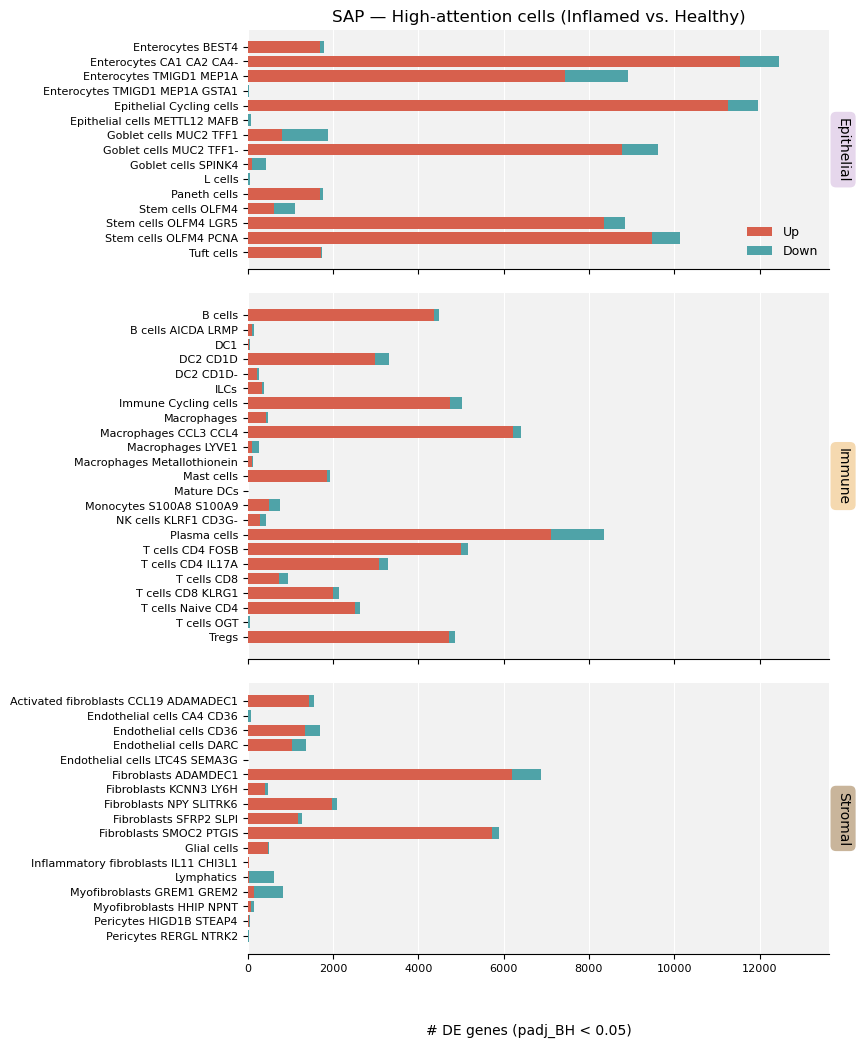

In [6]:
# Shared x-axis max across both panels for visual comparability
shared_xmax = max((sum_ha['Up'] + sum_ha['Down']).max(),
                  (sum_all['Up'] + sum_all['Down']).max()) * 1.05

fig_ha = plot_panel_A(sum_ha,  title='SAP — High-attention cells (Inflamed vs. Healthy)',
                       ax_xmax=shared_xmax,
                       savepath=os.path.join(FIG_DIR, 'panelA_high_attn.png'))
plt.show()

/tmp/ipykernel_461773/3346930435.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 0.97, 1])


saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/panelA_all_cells.png


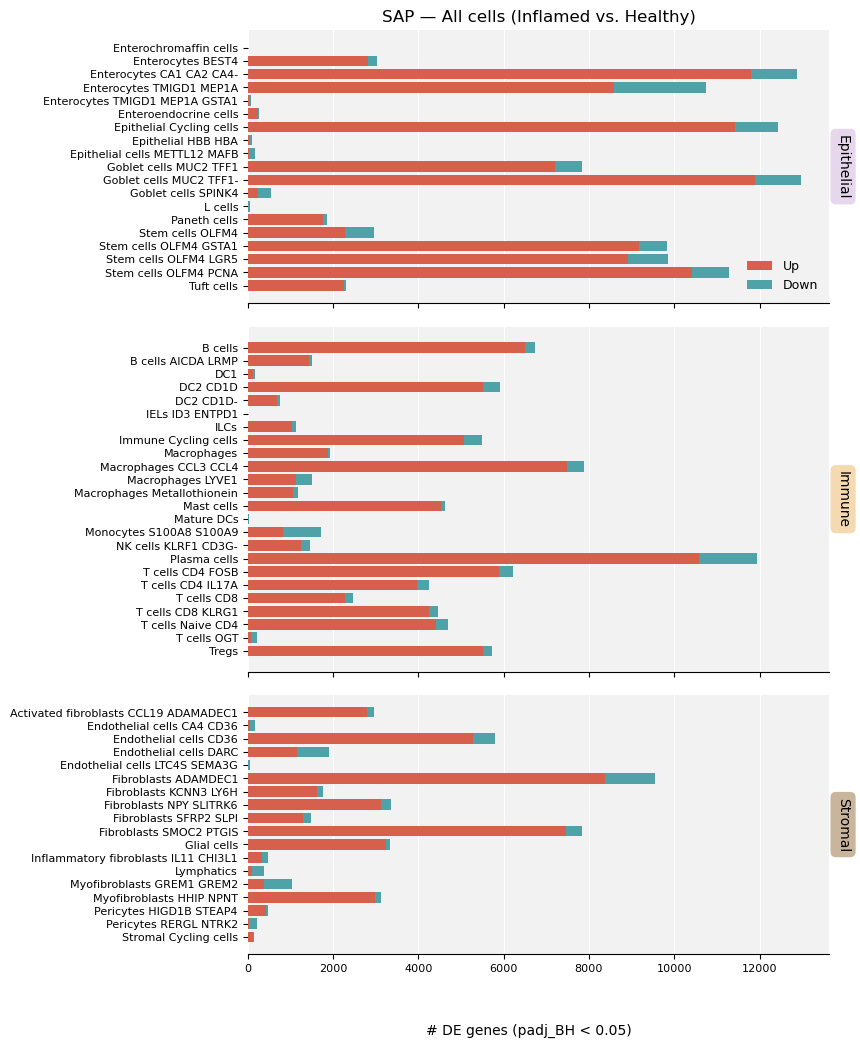

In [7]:
fig_all = plot_panel_A(sum_all, title='SAP — All cells (Inflamed vs. Healthy)',
                        ax_xmax=shared_xmax,
                        savepath=os.path.join(FIG_DIR, 'panelA_all_cells.png'))
plt.show()

In [8]:
# Tabular summaries written to disk for downstream use
sum_ha.to_csv(os.path.join(RESULTS_DIR, 'high_attn', 'de_counts_per_celltype.csv'),  index=False)
sum_all.to_csv(os.path.join(RESULTS_DIR, 'all_cells', 'de_counts_per_celltype.csv'), index=False)

merged = sum_ha.merge(sum_all, on=['cell_type', 'compartment'],
                       suffixes=('_high_attn', '_all_cells'), how='outer').fillna(0)
for c in ['Up_high_attn', 'Down_high_attn', 'Up_all_cells', 'Down_all_cells']:
    merged[c] = merged[c].astype(int)
merged.sort_values(['compartment', 'cell_type']).head(20)

,cell_type,Up_high_attn,Down_high_attn,compartment,Up_all_cells,Down_all_cells
11,Enterochromaffin cells,0,0,Epithelial,0,0
12,Enterocytes BEST4,1690,103,Epithelial,2809,217
13,Enterocytes CA1 CA2 CA4-,11553,902,Epithelial,11805,1072
14,Enterocytes TMIGD1 MEP1A,7435,1472,Epithelial,8593,2155
15,Enterocytes TMIGD1 MEP1A GSTA1,4,16,Epithelial,23,55
16,Enteroendocrine cells,0,0,Epithelial,229,37
17,Epithelial Cycling cells,11269,698,Epithelial,11433,1000
18,Epithelial HBB HBA,0,0,Epithelial,36,71
19,Epithelial cells METTL12 MAFB,6,61,Epithelial,29,143
26,Goblet cells MUC2 TFF1,795,1077,Epithelial,7207,627


## Figure-3C-style scatter — DE concordance: high-attn (x) vs all-cells (y)

For every (gene × cell_type) test that exists in **both** the high-attention and all-cells Wilcoxon runs, we plot:
- **x** = `logFC` from high_attn
- **y** = `logFC` from all_cells
- color = significance class (BH-adjusted *p* < `PADJ_CUT`):
  - grey  : non-significant in **both**
  - blue  : significant **only in all-cells**
  - green : significant **only in high-attn**
  - red   : significant in **both**
- orange line = OLS regression `y ~ x` per compartment, with slope and Pearson *r* annotated.

(gene x cell_type) pairs in common: 770778
sig_class
ns          543100
both        135435
all_only     80346
ha_only      11897
Name: count, dtype: int64


saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/panelC_logFC_concordance.png


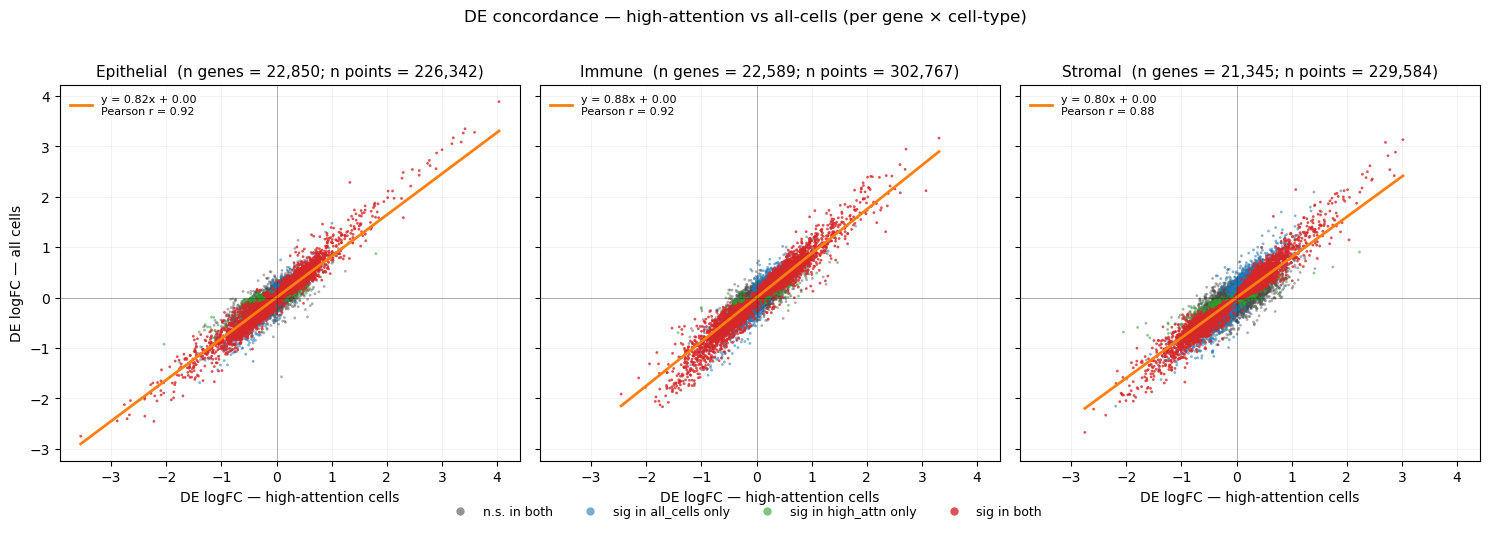

In [9]:
# Figure-3C-style scatter: high_attn logFC (x) vs all_cells logFC (y), per compartment
from scipy import stats

SIG_COLORS = {
    "ns":         ("#4D4D4D", 0.45, "n.s. in both"),
    "all_only":   ("#1f77b4", 0.55, "sig in all_cells only"),
    "ha_only":    ("#2ca02c", 0.55, "sig in high_attn only"),
    "both":       ("#d62728", 0.80, "sig in both"),
}
REG_COLOR  = "#FF7F0E"

def _prep(df):
    return df[["cell_type", "gene", "logFC", "padj_BH", "compartment"]].copy()

merged_de = _prep(de_ha).merge(
    _prep(de_all),
    on=["cell_type", "gene", "compartment"],
    suffixes=("_ha", "_all"),
    how="inner",
)

def _sig_class(row):
    sig_ha  = (row["padj_BH_ha"]  < PADJ_CUT) and not np.isnan(row["padj_BH_ha"])
    sig_all = (row["padj_BH_all"] < PADJ_CUT) and not np.isnan(row["padj_BH_all"])
    if sig_ha and sig_all: return "both"
    if sig_ha:             return "ha_only"
    if sig_all:            return "all_only"
    return "ns"

merged_de["sig_class"] = merged_de.apply(_sig_class, axis=1)
print("(gene x cell_type) pairs in common:", len(merged_de))
print(merged_de["sig_class"].value_counts())

def plot_concordance(df, savepath=None, point_size=4):
    comps = ["Epithelial", "Immune", "Stromal"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    for ax, comp in zip(axes, comps):
        sub = df[df["compartment"] == comp]
        if sub.empty:
            ax.set_title(f"{comp} (no data)"); continue

        # Plot in order so significant points sit on top
        for cls in ["ns", "all_only", "ha_only", "both"]:
            color, alpha, _ = SIG_COLORS[cls]
            d = sub[sub["sig_class"] == cls]
            if not len(d): continue
            ax.scatter(d["logFC_ha"], d["logFC_all"],
                       s=point_size, c=color, alpha=alpha,
                       edgecolors="none", rasterized=True)

        # OLS regression on all dots in this compartment
        x = sub["logFC_ha"].to_numpy(); y = sub["logFC_all"].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]
        if len(x) >= 2:
            slope, intercept, r, p, _ = stats.linregress(x, y)
            xs = np.linspace(x.min(), x.max(), 100)
            ax.plot(xs, slope * xs + intercept, color=REG_COLOR, lw=2,
                    label=f"y = {slope:.2f}x + {intercept:.2f}\nPearson r = {r:.2f}")
            ax.legend(loc="upper left", fontsize=8, frameon=False)

        ax.axhline(0, color="black", lw=0.5, alpha=0.4)
        ax.axvline(0, color="black", lw=0.5, alpha=0.4)
        ax.set_title(f"{comp}  (n genes = {sub['gene'].nunique():,}; n points = {len(sub):,})", fontsize=11)
        ax.set_xlabel("DE logFC — high-attention cells")
        ax.grid(True, alpha=0.2, lw=0.5)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("DE logFC — all cells")

    # Shared significance legend (bottom)
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], marker="o", linestyle="",
                      markerfacecolor=c, markeredgecolor="none",
                      markersize=6, alpha=max(a, 0.6), label=lbl)
               for (c, a, lbl) in SIG_COLORS.values()]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
               bbox_to_anchor=(0.5, -0.02), fontsize=9)

    fig.suptitle("DE concordance — high-attention vs all-cells (per gene × cell-type)",
                 fontsize=12, y=1.02)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
        print("saved ->", savepath)
    return fig

fig_c = plot_concordance(merged_de,
                         savepath=os.path.join(FIG_DIR, "panelC_logFC_concordance.png"))
plt.show()

## Per-cell-type concordance scatterplots

Same plot as above, but **one panel per cell type** (only cell types tested in *both* high-attn and all-cells runs). PNGs are saved under `figures/panelC_per_celltype/`.

In [10]:
# Per-cell-type Figure-3C-style scatter — high_attn (x) vs all_cells (y)
PER_CT_DIR = os.path.join(FIG_DIR, "panelC_per_celltype")
os.makedirs(PER_CT_DIR, exist_ok=True)

def safe_filename(s):
    return "".join(c if c.isalnum() or c in "._-" else "_" for c in str(s))

def plot_concordance_one_ct(sub, ct, comp, savepath, point_size=8):
    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    for cls in ["ns", "all_only", "ha_only", "both"]:
        color, alpha, _ = SIG_COLORS[cls]
        d = sub[sub["sig_class"] == cls]
        if not len(d): continue
        ax.scatter(d["logFC_ha"], d["logFC_all"],
                   s=point_size, c=color, alpha=alpha,
                   edgecolors="none", rasterized=True)

    x = sub["logFC_ha"].to_numpy(); y = sub["logFC_all"].to_numpy()
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    if len(x) >= 2 and np.ptp(x) > 0:
        slope, intercept, r, _, _ = stats.linregress(x, y)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, slope * xs + intercept, color=REG_COLOR, lw=2,
                label=f"y = {slope:.2f}x + {intercept:.2f}\nPearson r = {r:.2f}")
        ax.legend(loc="upper left", fontsize=8, frameon=False)

    ax.axhline(0, color="black", lw=0.5, alpha=0.4)
    ax.axvline(0, color="black", lw=0.5, alpha=0.4)
    ax.set_xlabel("DE logFC — high-attention cells")
    ax.set_ylabel("DE logFC — all cells")
    ax.set_title(f"{pretty(ct)}  [{comp}]\n"
                 f"n genes = {sub['gene'].nunique():,}",
                 fontsize=10)
    ax.grid(True, alpha=0.2, lw=0.5); ax.set_axisbelow(True)

    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], marker="o", linestyle="",
                      markerfacecolor=c, markeredgecolor="none",
                      markersize=5, alpha=max(a, 0.6), label=lbl)
               for (c, a, lbl) in SIG_COLORS.values()]
    ax.legend(handles=handles + ax.get_legend().legend_handles
                       if ax.get_legend() else handles,
              loc="best", fontsize=7, frameon=False)

    fig.tight_layout()
    fig.savefig(savepath, dpi=180, bbox_inches="tight")
    plt.close(fig)

# Iterate over cell types common to both runs
common_cts = sorted(merged_de["cell_type"].unique())
print(f"plotting {len(common_cts)} cell types -> {PER_CT_DIR}")

summary_rows = []
for ct in common_cts:
    sub  = merged_de[merged_de["cell_type"] == ct]
    if sub.empty: continue
    comp = sub["compartment"].iloc[0]
    out  = os.path.join(PER_CT_DIR, f"{safe_filename(ct)}.png")
    plot_concordance_one_ct(sub, ct, comp, out)

    x = sub["logFC_ha"].to_numpy(); y = sub["logFC_all"].to_numpy()
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    if len(x) >= 2 and np.ptp(x) > 0:
        slope, intercept, r, p, _ = stats.linregress(x, y)
    else:
        slope = intercept = r = p = np.nan
    summary_rows.append({
        "cell_type": ct, "compartment": comp,
        "n_genes": sub["gene"].nunique(),
        "n_points": len(sub),
        "slope": slope, "intercept": intercept,
        "pearson_r": r, "pearson_p": p,
        "n_sig_both":     int((sub["sig_class"] == "both").sum()),
        "n_sig_ha_only":  int((sub["sig_class"] == "ha_only").sum()),
        "n_sig_all_only": int((sub["sig_class"] == "all_only").sum()),
        "n_ns":           int((sub["sig_class"] == "ns").sum()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["compartment", "cell_type"])
summary_csv = os.path.join(PER_CT_DIR, "_concordance_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print("saved summary ->", summary_csv)
summary_df.head(15)

plotting 56 cell types -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/panelC_per_celltype


saved summary -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/panelC_per_celltype/_concordance_summary.csv


,cell_type,compartment,n_genes,n_points,slope,intercept,pearson_r,pearson_p,n_sig_both,n_sig_ha_only,n_sig_all_only,n_ns
10,Enterocytes BEST4,Epithelial,15396,15396,0.904569,0.006338,0.943861,0.0,1516,277,1259,12344
11,Enterocytes CA1 CA2 CA4-,Epithelial,19085,19085,0.982423,-0.001886,0.966616,0.0,11681,774,849,5781
12,Enterocytes TMIGD1 MEP1A,Epithelial,19292,19292,1.002476,-0.001904,0.947665,0.0,8263,644,2431,7954
13,Enterocytes TMIGD1 MEP1A GSTA1,Epithelial,8904,8904,0.714500,0.003194,0.856080,0.0,19,1,59,8825
14,Epithelial Cycling cells,Epithelial,18599,18599,0.855836,-0.004574,0.962111,0.0,11427,540,978,5654
15,Epithelial cells METTL12 MAFB,Epithelial,10429,10429,0.799868,-0.003473,0.893116,0.0,61,6,111,10251
22,Goblet cells MUC2 TFF1,Epithelial,16171,16171,0.673259,0.016470,0.857931,0.0,1216,656,6613,7686
23,Goblet cells MUC2 TFF1-,Epithelial,19108,19108,1.024686,0.006611,0.978255,0.0,9409,212,3531,5956
24,Goblet cells SPINK4,Epithelial,11146,11146,0.885294,0.006013,0.985658,0.0,343,86,193,10524
28,L cells,Epithelial,10384,10384,0.634272,0.022639,0.848256,0.0,26,15,27,10316


## Figure-3F-style fgsea panel — Immune C7 pathways

For each mode (high-attn, all-cells) we look at the fgsea **C7** results restricted to **Immune** cell types and plot, per pathway, the **fraction of immune cell types** in which the pathway is significant (`padj < 0.05`), split by enrichment direction:
- **right (red)**  → fraction of immune CTs where the pathway is significantly **up** (NES > 0)
- **left (teal)** → fraction of immune CTs where the pathway is significantly **down** (NES < 0)

Pathways shown: those significant in **≥10% of immune cell types** in at least one direction.

[high-attention cells] no pathways pass >= 70% frac in immune CTs


[all cells] saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/panelF_c7_immune_all_cells.png  (2 pathways, 24 immune CTs)


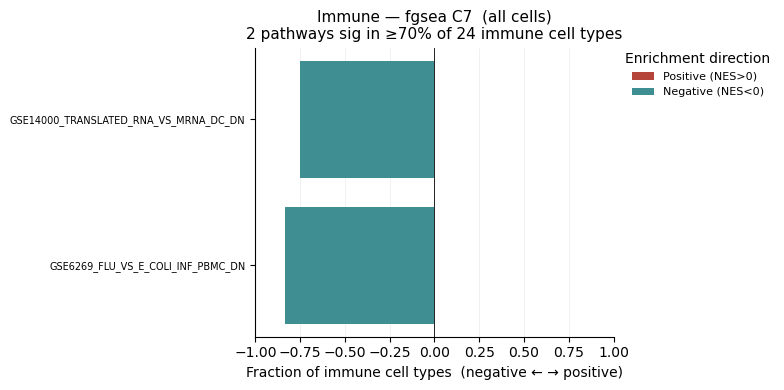

In [11]:
# Figure-3F-style fgsea C7 panels — Immune only
FRAC_CUT = 0.70
POS_COL  = "#B5443A"
NEG_COL  = "#3F8E92"

def load_fgsea(mode_dir, collection="c7"):
    df = pd.read_csv(os.path.join(mode_dir, f"fgsea_{collection}_combined.csv"))
    df["compartment"] = df["cell_type"].map(assign_compartment)
    return df

def immune_pathway_fractions(fg_df, padj_cut=PADJ_CUT):
    imm = fg_df[fg_df["compartment"] == "Immune"].copy()
    n_ct = imm["cell_type"].nunique()
    sig  = imm[imm["padj"] < padj_cut]
    pos  = (sig[sig["NES"] > 0].groupby("pathway").size().rename("n_pos"))
    neg  = (sig[sig["NES"] < 0].groupby("pathway").size().rename("n_neg"))
    out  = pd.concat([pos, neg], axis=1).fillna(0).astype(int)
    out["frac_pos"] =  out["n_pos"] / n_ct
    out["frac_neg"] = -out["n_neg"] / n_ct  # negative for left-side bar
    out["frac_any"] = (out["n_pos"] + out["n_neg"]) / n_ct
    return out.reset_index(), n_ct

def plot_panel_F_immune(fg_df, mode_label, savepath, max_pathways=200, figsize=None):
    frac, n_ct = immune_pathway_fractions(fg_df)
    kept = frac[frac["frac_any"] >= FRAC_CUT].copy()
    if kept.empty:
        print(f"[{mode_label}] no pathways pass >= {FRAC_CUT:.0%} frac in immune CTs")
        return None

    # Cap pathway count for legibility; rank by total presence
    kept = kept.sort_values("frac_any", ascending=False).head(max_pathways)
    kept = kept.sort_values("frac_pos", ascending=True)  # plotting order bottom->top
    ypos = np.arange(len(kept))

    if figsize is None:
        figsize = (8, max(4, 0.22 * len(kept) + 1.5))
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(ypos, kept["frac_pos"], color=POS_COL, edgecolor="none", label="Positive (NES>0)")
    ax.barh(ypos, kept["frac_neg"], color=NEG_COL, edgecolor="none", label="Negative (NES<0)")
    ax.axvline(0, color="black", lw=0.6)
    ax.set_yticks(ypos)
    ax.set_yticklabels(kept["pathway"], fontsize=7)
    ax.set_xlim(-1, 1)
    ax.set_xlabel("Fraction of immune cell types  (negative ← → positive)")
    ax.set_title(f"Immune — fgsea C7  ({mode_label})\n"
                 f"{len(kept)} pathways sig in ≥{FRAC_CUT:.0%} of {n_ct} immune cell types",
                 fontsize=11)
    ax.grid(axis="x", alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False,
              fontsize=8, title="Enrichment direction", borderaxespad=0)
    fig.tight_layout()
    fig.savefig(savepath, dpi=200, bbox_inches="tight")
    print(f"[{mode_label}] saved -> {savepath}  ({len(kept)} pathways, {n_ct} immune CTs)")
    return fig

fg_ha  = load_fgsea(os.path.join(RESULTS_DIR, "high_attn"),  "c7")
fg_all = load_fgsea(os.path.join(RESULTS_DIR, "all_cells"), "c7")

fig_f_ha  = plot_panel_F_immune(fg_ha,  "high-attention cells",
                                 os.path.join(FIG_DIR, "panelF_c7_immune_high_attn.png"))
plt.show()
fig_f_all = plot_panel_F_immune(fg_all, "all cells",
                                 os.path.join(FIG_DIR, "panelF_c7_immune_all_cells.png"))
plt.show()

## Pathway set comparison — high-attn vs all-cells (immune, C7)

For the same `FRAC_CUT` used above, identify which pathways are:
- **only in high_attn** (high-attn-specific)
- **only in all_cells** (all-cells-specific)
- **shared** between the two

Outputs both a printed summary and a CSV: `results/immune_c7_pathway_set_compare.csv`.

In [12]:
# Set comparison of immune C7 pathways passing FRAC_CUT in each mode
def pathways_above_cut(fg_df, frac_cut=FRAC_CUT, padj_cut=PADJ_CUT):
    frac, n_ct = immune_pathway_fractions(fg_df, padj_cut=padj_cut)
    kept = frac[frac["frac_any"] >= frac_cut].copy()
    kept = kept.set_index("pathway")
    return kept, n_ct

# Full per-pathway frac tables (no threshold) so we can show TRUE fractions even
# when one side falls below FRAC_CUT.
frac_ha_full,  n_ha  = immune_pathway_fractions(fg_ha)
frac_all_full, n_all = immune_pathway_fractions(fg_all)
frac_ha_full  = frac_ha_full.set_index("pathway")
frac_all_full = frac_all_full.set_index("pathway")

ha_kept  = frac_ha_full[frac_ha_full["frac_any"]   >= FRAC_CUT]
all_kept = frac_all_full[frac_all_full["frac_any"] >= FRAC_CUT]

ha_only    = sorted(set(ha_kept.index)  - set(all_kept.index))
all_only   = sorted(set(all_kept.index) - set(ha_kept.index))
shared     = sorted(set(ha_kept.index)  & set(all_kept.index))

print(f"FRAC_CUT = {FRAC_CUT:.0%},  PADJ_CUT = {PADJ_CUT}")
print(f"  high_attn ({n_ha} immune CTs)  : {len(ha_kept):>4} pathways")
print(f"  all_cells ({n_all} immune CTs) : {len(all_kept):>4} pathways")
print(f"  shared                          : {len(shared):>4}")
print(f"  high_attn-only                  : {len(ha_only):>4}")
print(f"  all_cells-only                  : {len(all_only):>4}")

def _row(p):
    in_ha  = p in ha_kept.index
    in_all = p in all_kept.index
    presence = ("shared" if (in_ha and in_all)
                else "high_attn_only" if in_ha
                else "all_cells_only")
    ha_r  = frac_ha_full.loc[p]  if p in frac_ha_full.index  else None
    all_r = frac_all_full.loc[p] if p in frac_all_full.index else None
    return {
        "pathway": p, "presence": presence,
        "frac_any_high_attn": float(ha_r["frac_any"])  if ha_r  is not None else 0.0,
        "frac_pos_high_attn": float(ha_r["frac_pos"])  if ha_r  is not None else 0.0,
        "frac_neg_high_attn": float(ha_r["frac_neg"])  if ha_r  is not None else 0.0,
        "frac_any_all_cells": float(all_r["frac_any"]) if all_r is not None else 0.0,
        "frac_pos_all_cells": float(all_r["frac_pos"]) if all_r is not None else 0.0,
        "frac_neg_all_cells": float(all_r["frac_neg"]) if all_r is not None else 0.0,
    }

all_paths = sorted(set(ha_kept.index) | set(all_kept.index))
compare_df = pd.DataFrame([_row(p) for p in all_paths])
compare_df["delta_frac"] = compare_df["frac_any_high_attn"] - compare_df["frac_any_all_cells"]
compare_df = compare_df.sort_values(["presence", "frac_any_high_attn"], ascending=[True, False])
out_csv = os.path.join(RESULTS_DIR, "immune_c7_pathway_set_compare.csv")
compare_df.to_csv(out_csv, index=False)
print(f"\nsaved -> {out_csv}\n")

print("=== high_attn-only pathways (true fractions shown for both modes) ===")
ho = compare_df[compare_df.presence == "high_attn_only"]
print(ho[["pathway", "frac_any_high_attn", "frac_any_all_cells", "delta_frac",
         "frac_pos_high_attn", "frac_neg_high_attn"]].to_string(index=False))

compare_df.head(30)

FRAC_CUT = 70%,  PADJ_CUT = 0.05
  high_attn (23 immune CTs)  :    0 pathways
  all_cells (24 immune CTs) :    2 pathways
  shared                          :    0
  high_attn-only                  :    0
  all_cells-only                  :    2

saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/immune_c7_pathway_set_compare.csv

=== high_attn-only pathways (true fractions shown for both modes) ===
Empty DataFrame
Columns: [pathway, frac_any_high_attn, frac_any_all_cells, delta_frac, frac_pos_high_attn, frac_neg_high_attn]
Index: []


,pathway,presence,frac_any_high_attn,frac_pos_high_attn,frac_neg_high_attn,frac_any_all_cells,frac_pos_all_cells,frac_neg_all_cells,delta_frac
1,GSE6269_FLU_VS_E_COLI_INF_PBMC_DN,all_cells_only,0.695652,0.0,-0.695652,0.833333,0.0,-0.833333,-0.137681
0,GSE14000_TRANSLATED_RNA_VS_MRNA_DC_DN,all_cells_only,0.652174,0.0,-0.652174,0.750000,0.0,-0.750000,-0.097826


## Full immune C7 pathway delta table

Compute, for **every C7 pathway tested in immune cell types**, the fraction of immune CTs in which the pathway is significant (`padj<0.05`), separately for high-attn and all-cells. Build a single table sorted by `delta_frac = frac_any_high_attn − frac_any_all_cells` to surface pathways most differentially enriched between the two runs.

Outputs:
- `results/immune_c7_full_delta.csv`        — all pathways
- Console: top 20 high-attn-enriched and top 20 all-cells-enriched pathways.

In [13]:
# Full immune C7 pathway delta table (no FRAC_CUT filter)
def _full_frac(fg_df, padj_cut=PADJ_CUT):
    imm  = fg_df[fg_df["compartment"] == "Immune"].copy()
    n_ct = imm["cell_type"].nunique()
    sig  = imm[imm["padj"] < padj_cut]
    pos  = sig[sig["NES"] > 0].groupby("pathway").size().rename("n_pos")
    neg  = sig[sig["NES"] < 0].groupby("pathway").size().rename("n_neg")
    # All pathways tested in immune CTs (even with 0 sig hits)
    all_paths = imm["pathway"].unique()
    out = pd.DataFrame(index=pd.Index(all_paths, name="pathway"))
    out = out.join(pos).join(neg).fillna(0).astype({"n_pos": int, "n_neg": int})
    out["frac_pos"] = out["n_pos"] / n_ct
    out["frac_neg"] = out["n_neg"] / n_ct
    out["frac_any"] = (out["n_pos"] + out["n_neg"]) / n_ct
    out["n_ct"]     = n_ct
    return out

full_ha  = _full_frac(fg_ha).add_suffix("_high_attn")
full_all = _full_frac(fg_all).add_suffix("_all_cells")

full = full_ha.join(full_all, how="outer").fillna(0)
full["delta_frac"]     = full["frac_any_high_attn"] - full["frac_any_all_cells"]
full["delta_frac_pos"] = full["frac_pos_high_attn"] - full["frac_pos_all_cells"]
full["delta_frac_neg"] = full["frac_neg_high_attn"] - full["frac_neg_all_cells"]
full = full.sort_values("delta_frac", ascending=False).reset_index()

out_csv = os.path.join(RESULTS_DIR, "immune_c7_full_delta.csv")
full.to_csv(out_csv, index=False)
print(f"saved {len(full):,} pathways -> {out_csv}\n")

cols = ["pathway", "frac_any_high_attn", "frac_any_all_cells", "delta_frac",
        "frac_pos_high_attn", "frac_neg_high_attn"]

print("=== Top 20 pathways MORE enriched in high_attn (high positive delta) ===")
print(full[cols].head(20).to_string(index=False))

print("\n=== Top 20 pathways MORE enriched in all_cells (most negative delta) ===")
print(full[cols].tail(20).iloc[::-1].to_string(index=False))

saved 4,872 pathways -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/immune_c7_full_delta.csv

=== Top 20 pathways MORE enriched in high_attn (high positive delta) ===
                                                                   pathway  frac_any_high_attn  frac_any_all_cells  delta_frac  frac_pos_high_attn  frac_neg_high_attn
                  GSE16450_CTRL_VS_IFNA_6H_STIM_MATURE_NEURON_CELL_LINE_DN            0.347826            0.083333    0.264493            0.347826            0.000000
GSE9316_CD4_TCELL_BALBC_VS_TH17_ENRI_CD4_TCELL_SKG_PMA_IONO_STIM_FR4NEG_DN            0.391304            0.166667    0.224638            0.391304            0.000000
                  GSE41087_WT_VS_FOXP3_MUT_ANTI_CD3_CD28_STIM_CD4_TCELL_UP            0.347826            0.125000    0.222826            0.260870            0.086957
    

## Notes
- 'Other' compartment (e.g. unlabeled `Cycling_cells`) is dropped from the plot but retained in CSVs.
- Significance uses BH-adjusted Wilcoxon p-value (`padj_BH < 0.05`). To change, edit `PADJ_CUT` at the top.
- Sign convention matches `wilcox_de.py`: `logFC = mean(log1p CP10k)_Inflamed − _Normal`.

## Hallmark pathway delta table — all cell types

For **every Hallmark (H) pathway** tested in the fgsea runs, compute the fraction of **all cell types** in which the pathway is significant (`padj < PADJ_CUT`), separately for high-attn and all-cells, and tabulate the difference (`delta_frac = frac_any_high_attn − frac_any_all_cells`).

This mirrors `results/immune_c7_full_delta.csv` but:
- uses the **Hallmark** collection instead of C7
- includes **all cell types** (no compartment filter)

Outputs:
- `results/hallmark_all_celltypes/hallmark_all_celltypes_full_delta.csv` — all pathways


In [14]:
# Hallmark pathway delta table across ALL cell types
HALLMARK_DIR = os.path.join(RESULTS_DIR, "hallmark_all_celltypes")
os.makedirs(HALLMARK_DIR, exist_ok=True)

fg_h_ha  = load_fgsea(os.path.join(RESULTS_DIR, "high_attn"),  "h")
fg_h_all = load_fgsea(os.path.join(RESULTS_DIR, "all_cells"), "h")

def _full_frac_all_cts(fg_df, padj_cut=PADJ_CUT):
    n_ct = fg_df["cell_type"].nunique()
    sig  = fg_df[fg_df["padj"] < padj_cut]
    pos  = sig[sig["NES"] > 0].groupby("pathway").size().rename("n_pos")
    neg  = sig[sig["NES"] < 0].groupby("pathway").size().rename("n_neg")
    all_paths = fg_df["pathway"].unique()
    out = pd.DataFrame(index=pd.Index(all_paths, name="pathway"))
    out = out.join(pos).join(neg).fillna(0).astype({"n_pos": int, "n_neg": int})
    out["frac_pos"] = out["n_pos"] / n_ct
    out["frac_neg"] = out["n_neg"] / n_ct
    out["frac_any"] = (out["n_pos"] + out["n_neg"]) / n_ct
    out["n_ct"]     = n_ct
    return out

full_h_ha  = _full_frac_all_cts(fg_h_ha).add_suffix("_high_attn")
full_h_all = _full_frac_all_cts(fg_h_all).add_suffix("_all_cells")

full_h = full_h_ha.join(full_h_all, how="outer").fillna(0)
full_h["delta_frac"]     = full_h["frac_any_high_attn"] - full_h["frac_any_all_cells"]
full_h["delta_frac_pos"] = full_h["frac_pos_high_attn"] - full_h["frac_pos_all_cells"]
full_h["delta_frac_neg"] = full_h["frac_neg_high_attn"] - full_h["frac_neg_all_cells"]
full_h = full_h.sort_values("delta_frac", ascending=False).reset_index()

out_csv_h = os.path.join(HALLMARK_DIR, "hallmark_all_celltypes_full_delta.csv")
full_h.to_csv(out_csv_h, index=False)
print(f"saved {len(full_h):,} hallmark pathways -> {out_csv_h}\n")

cols = ["pathway", "frac_any_high_attn", "frac_any_all_cells", "delta_frac",
        "frac_pos_high_attn", "frac_neg_high_attn"]

print("=== Top 20 Hallmark pathways MORE enriched in high_attn ===")
print(full_h[cols].head(20).to_string(index=False))

print("\n=== Top 20 Hallmark pathways MORE enriched in all_cells ===")
print(full_h[cols].tail(20).iloc[::-1].to_string(index=False))


saved 50 hallmark pathways -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/hallmark_all_celltypes/hallmark_all_celltypes_full_delta.csv

=== Top 20 Hallmark pathways MORE enriched in high_attn ===
                            pathway  frac_any_high_attn  frac_any_all_cells  delta_frac  frac_pos_high_attn  frac_neg_high_attn
                   HALLMARK_HYPOXIA            0.357143            0.238095    0.119048            0.089286            0.267857
            HALLMARK_MYC_TARGETS_V1            0.517857            0.412698    0.105159            0.089286            0.428571
               HALLMARK_P53_PATHWAY            0.232143            0.126984    0.105159            0.017857            0.214286
                HALLMARK_MYOGENESIS            0.142857            0.047619    0.095238            0.017857            0.125000
   

### Per-cell-type Hallmark comparison CSVs

For every cell type tested in **both** the high-attn and all-cells fgsea Hallmark runs, write one CSV containing every Hallmark pathway with side-by-side `NES`, `padj`, leading-edge genes, and a `sig_class` flag (`both` / `ha_only` / `all_only` / `ns`).

Files are written to `results/hallmark_all_celltypes/per_celltype/<cell_type>.csv`.


In [15]:
# Per-cell-type Hallmark comparison CSVs (cell types common to both modes)
PER_CT_H_DIR = os.path.join(HALLMARK_DIR, "per_celltype")
os.makedirs(PER_CT_H_DIR, exist_ok=True)

def safe_fn(s):
    return "".join(c if c.isalnum() or c in "._-" else "_" for c in str(s))

cols_keep = ["pathway", "NES", "padj", "pval", "ES", "size", "leadingEdge"]
ha_df  = fg_h_ha[cols_keep + ["cell_type"]].copy()
all_df = fg_h_all[cols_keep + ["cell_type"]].copy()

common_cts_h = sorted(set(ha_df["cell_type"]).intersection(all_df["cell_type"]))
print(f"writing per-cell-type Hallmark CSVs for {len(common_cts_h)} cell types -> {PER_CT_H_DIR}")

summary_rows_h = []
for ct in common_cts_h:
    sub_ha  = ha_df [ha_df ["cell_type"] == ct].drop(columns=["cell_type"])
    sub_all = all_df[all_df["cell_type"] == ct].drop(columns=["cell_type"])
    merged = sub_ha.merge(sub_all, on="pathway", how="outer",
                          suffixes=("_high_attn", "_all_cells"))

    sig_ha  = merged["padj_high_attn"].lt(PADJ_CUT).fillna(False)
    sig_all = merged["padj_all_cells"].lt(PADJ_CUT).fillna(False)
    merged["sig_class"] = np.select(
        [sig_ha & sig_all, sig_ha & ~sig_all, ~sig_ha & sig_all],
        ["both", "ha_only", "all_only"],
        default="ns",
    )
    merged["delta_NES"] = merged["NES_high_attn"] - merged["NES_all_cells"]
    merged = merged.sort_values(["sig_class", "delta_NES"],
                                key=lambda s: s.map({"both":0,"ha_only":1,"all_only":2,"ns":3})
                                              if s.name == "sig_class" else -s.abs(),
                                ascending=[True, True])

    merged = merged[merged["sig_class"] != "ns"].copy()
    if merged.empty:
        continue
    out_path = os.path.join(PER_CT_H_DIR, f"{safe_fn(ct)}.csv")
    merged.to_csv(out_path, index=False)

    summary_rows_h.append({
        "cell_type":    ct,
        "n_pathways":   len(merged),
        "n_sig_both":   int((merged["sig_class"] == "both").sum()),
        "n_sig_ha_only":  int((merged["sig_class"] == "ha_only").sum()),
        "n_sig_all_only": int((merged["sig_class"] == "all_only").sum()),
        "n_ns":           int((merged["sig_class"] == "ns").sum()),
    })

summary_h = pd.DataFrame(summary_rows_h).sort_values("n_sig_both", ascending=False)
summary_path_h = os.path.join(PER_CT_H_DIR, "_per_celltype_summary.csv")
summary_h.to_csv(summary_path_h, index=False)
print(f"saved summary -> {summary_path_h}")
summary_h.head(15)


writing per-cell-type Hallmark CSVs for 56 cell types -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/hallmark_all_celltypes/per_celltype


saved summary -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/hallmark_all_celltypes/per_celltype/_per_celltype_summary.csv


,cell_type,n_pathways,n_sig_both,n_sig_ha_only,n_sig_all_only,n_ns
8,Endothelial_cells_DARC,24,17,2,5,0
36,Myofibroblasts_GREM1_GREM2,18,16,0,2,0
33,Macrophages_Metallothionein,20,16,3,1,0
31,Macrophages_CCL3_CCL4,20,15,2,3,0
35,Monocytes_S100A8_S100A9,25,15,10,0,0
42,Pericytes_RERGL_NTRK2,22,14,4,4,0
6,Endothelial_cells_CA4_CD36,24,13,9,2,0
19,Fibroblasts_SFRP2_SLPI,17,13,3,1,0
34,Mature_DCs,15,12,3,0,0
17,Fibroblasts_KCNN3_LY6H,11,10,1,0,0


## C7 pathway delta + per-cell-type comparison CSVs (all cell types)

Same analysis as the Hallmark section above, but using the **C7 (immunologic signatures)** collection and including **all cell types** (no compartment filter).

Outputs:
- `results/c7_all_celltypes/c7_all_celltypes_full_delta.csv` — fraction of cell types each C7 pathway is significant in (high_attn vs all_cells, with delta)
- `results/c7_all_celltypes/per_celltype/<cell_type>.csv` — per-CT side-by-side NES/padj/leadingEdge with `sig_class`. Pathways not significant in either mode are dropped.
- `results/c7_all_celltypes/per_celltype/_per_celltype_summary.csv` — per-CT counts of significance classes.


In [16]:
# C7 delta table + per-cell-type comparison CSVs (all cell types, sig-only)
C7_DIR = os.path.join(RESULTS_DIR, "c7_all_celltypes")
PER_CT_C7_DIR = os.path.join(C7_DIR, "per_celltype")
os.makedirs(PER_CT_C7_DIR, exist_ok=True)

fg_c7_ha  = load_fgsea(os.path.join(RESULTS_DIR, "high_attn"),  "c7")
fg_c7_all = load_fgsea(os.path.join(RESULTS_DIR, "all_cells"), "c7")

# --- Full pathway delta across all cell types ---
full_c7_ha  = _full_frac_all_cts(fg_c7_ha).add_suffix("_high_attn")
full_c7_all = _full_frac_all_cts(fg_c7_all).add_suffix("_all_cells")

full_c7 = full_c7_ha.join(full_c7_all, how="outer").fillna(0)
full_c7["delta_frac"]     = full_c7["frac_any_high_attn"] - full_c7["frac_any_all_cells"]
full_c7["delta_frac_pos"] = full_c7["frac_pos_high_attn"] - full_c7["frac_pos_all_cells"]
full_c7["delta_frac_neg"] = full_c7["frac_neg_high_attn"] - full_c7["frac_neg_all_cells"]
full_c7 = full_c7.sort_values("delta_frac", ascending=False).reset_index()

out_csv_c7 = os.path.join(C7_DIR, "c7_all_celltypes_full_delta.csv")
full_c7.to_csv(out_csv_c7, index=False)
print(f"saved {len(full_c7):,} C7 pathways -> {out_csv_c7}\n")

# --- Per-cell-type C7 comparison CSVs ---
cols_keep = ["pathway", "NES", "padj", "pval", "ES", "size", "leadingEdge"]
ha_c7  = fg_c7_ha [cols_keep + ["cell_type"]].copy()
all_c7 = fg_c7_all[cols_keep + ["cell_type"]].copy()

common_cts_c7 = sorted(set(ha_c7["cell_type"]).intersection(all_c7["cell_type"]))
print(f"writing per-cell-type C7 CSVs for {len(common_cts_c7)} cell types -> {PER_CT_C7_DIR}")

summary_rows_c7 = []
for ct in common_cts_c7:
    sub_ha  = ha_c7 [ha_c7 ["cell_type"] == ct].drop(columns=["cell_type"])
    sub_all = all_c7[all_c7["cell_type"] == ct].drop(columns=["cell_type"])
    merged = sub_ha.merge(sub_all, on="pathway", how="outer",
                          suffixes=("_high_attn", "_all_cells"))

    sig_ha  = merged["padj_high_attn"].lt(PADJ_CUT).fillna(False)
    sig_all = merged["padj_all_cells"].lt(PADJ_CUT).fillna(False)
    merged["sig_class"] = np.select(
        [sig_ha & sig_all, sig_ha & ~sig_all, ~sig_ha & sig_all],
        ["both", "ha_only", "all_only"],
        default="ns",
    )
    merged["delta_NES"] = merged["NES_high_attn"] - merged["NES_all_cells"]

    merged = merged[merged["sig_class"] != "ns"].copy()
    if merged.empty:
        continue

    merged = merged.sort_values(["sig_class", "delta_NES"],
                                key=lambda s: s.map({"both":0,"ha_only":1,"all_only":2,"ns":3})
                                              if s.name == "sig_class" else -s.abs(),
                                ascending=[True, True])

    out_path = os.path.join(PER_CT_C7_DIR, f"{safe_fn(ct)}.csv")
    merged.to_csv(out_path, index=False)

    summary_rows_c7.append({
        "cell_type":      ct,
        "n_pathways":     len(merged),
        "n_sig_both":     int((merged["sig_class"] == "both").sum()),
        "n_sig_ha_only":  int((merged["sig_class"] == "ha_only").sum()),
        "n_sig_all_only": int((merged["sig_class"] == "all_only").sum()),
    })

summary_c7 = pd.DataFrame(summary_rows_c7).sort_values("n_sig_both", ascending=False)
summary_path_c7 = os.path.join(PER_CT_C7_DIR, "_per_celltype_summary.csv")
summary_c7.to_csv(summary_path_c7, index=False)
print(f"saved summary -> {summary_path_c7}")
summary_c7.head(15)


saved 4,872 C7 pathways -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/c7_all_celltypes/c7_all_celltypes_full_delta.csv

writing per-cell-type C7 CSVs for 56 cell types -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/c7_all_celltypes/per_celltype


saved summary -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/c7_all_celltypes/per_celltype/_per_celltype_summary.csv


,cell_type,n_pathways,n_sig_both,n_sig_ha_only,n_sig_all_only
35,Monocytes_S100A8_S100A9,1535,1083,337,115
33,Macrophages_Metallothionein,1026,697,170,159
31,Macrophages_CCL3_CCL4,1024,693,279,52
4,DC2_CD1D,752,559,40,153
51,T_cells_OGT,690,417,127,146
34,Mature_DCs,821,416,344,61
26,Immune_Cycling_cells,558,354,150,54
29,Lymphatics,500,237,170,93
32,Macrophages_LYVE1,493,231,74,188
8,Endothelial_cells_DARC,408,230,46,132


## Per-cell-type two-panel Hallmark plot — high_attn vs all_cells

For every cell type tested in both modes, draw a horizontal bar plot with:
- **Y axis** = Hallmark pathways significant (`padj < PADJ_CUT`) in *either* mode for that cell type
- **X axis** = signed NES (positive → enriched in Inflamed, negative → enriched in Normal)
- **Two side-by-side panels**: high-attention cells (left), all cells (right)
- Colour: red for NES > 0, teal for NES < 0; faded bar if not significant in that mode

Pathways are sorted by the mean NES across the two modes so that strongly positive ones are at the top and strongly negative at the bottom.

Output: `figures/hallmark_per_celltype_bipanel/<cell_type>.png`


In [17]:
# Per-cell-type 2-panel Hallmark bar plot (high_attn | all_cells)
HALL_FIG_DIR = os.path.join(FIG_DIR, "hallmark_per_celltype_bipanel")
os.makedirs(HALL_FIG_DIR, exist_ok=True)

# Bar colours by sig_class (same colour for +/- NES)
CLASS_COLORS = {
    "both":     "#6A3D9A",  # purple — sig in both
    "ha_only":  "#2CA02C",  # green  — sig only in high-attn
    "all_only": "#1F77B4",  # blue   — sig only in all-cells
}
NONSIG_ALPHA = 0.30  # fade bars in the panel where the pathway is not significant

cols_keep = ["pathway", "NES", "padj", "cell_type"]
h_ha_df  = fg_h_ha [cols_keep].copy()
h_all_df = fg_h_all[cols_keep].copy()

common_cts_hp = sorted(set(h_ha_df["cell_type"]).intersection(h_all_df["cell_type"]))
print(f"plotting Hallmark bipanel for {len(common_cts_hp)} cell types -> {HALL_FIG_DIR}")

def _bar_panel(ax, df, title):
    if df.empty:
        ax.set_title(title + " (no data)"); return
    colors = [CLASS_COLORS[c] for c in df["sig_class"]]
    alphas = [1.0 if s else NONSIG_ALPHA for s in df["sig"]]
    ypos = np.arange(len(df))
    bars = ax.barh(ypos, df["NES"].fillna(0), color=colors, edgecolor="none")
    for b, a in zip(bars, alphas):
        b.set_alpha(a)
    ax.axvline(0, color="black", lw=0.6)
    ax.set_yticks(ypos)
    ax.set_yticklabels(df["pathway"], fontsize=10)
    ax.set_xlabel("NES  (Normal \u2190 0 \u2192 Inflamed)")
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)

for ct in common_cts_hp:
    sub_ha  = h_ha_df [h_ha_df ["cell_type"] == ct].drop(columns="cell_type")
    sub_all = h_all_df[h_all_df["cell_type"] == ct].drop(columns="cell_type")
    merged = sub_ha.merge(sub_all, on="pathway", how="outer",
                          suffixes=("_high_attn", "_all_cells"))

    sig_ha  = merged["padj_high_attn"].lt(PADJ_CUT).fillna(False)
    sig_all = merged["padj_all_cells"].lt(PADJ_CUT).fillna(False)
    keep = sig_ha | sig_all
    merged = merged[keep].copy()
    sig_ha  = sig_ha[keep].reset_index(drop=True)
    sig_all = sig_all[keep].reset_index(drop=True)
    merged = merged.reset_index(drop=True)
    if merged.empty:
        continue

    merged["sig_class"] = np.where(sig_ha & sig_all, "both",
                          np.where(sig_ha, "ha_only", "all_only"))
    merged["mean_NES"] = merged[["NES_high_attn", "NES_all_cells"]].mean(axis=1)
    order = merged["mean_NES"].sort_values(ascending=True).index
    merged = merged.loc[order].reset_index(drop=True)
    sig_ha  = sig_ha.loc[order].reset_index(drop=True)
    sig_all = sig_all.loc[order].reset_index(drop=True)

    ha_panel  = pd.DataFrame({"pathway": merged["pathway"],
                              "NES":     merged["NES_high_attn"],
                              "sig":     sig_ha,
                              "sig_class": merged["sig_class"]})
    all_panel = pd.DataFrame({"pathway": merged["pathway"],
                              "NES":     merged["NES_all_cells"],
                              "sig":     sig_all,
                              "sig_class": merged["sig_class"]})

    n_paths = len(merged)
    fig, axes = plt.subplots(1, 2, figsize=(11, max(3.0, 0.28 * n_paths + 1.5)),
                             sharey=True)
    _bar_panel(axes[0], ha_panel,  "high-attention cells")
    _bar_panel(axes[1], all_panel, "all cells")
    fig.suptitle(f"{pretty(ct)} \u2014 Hallmark pathways (sig in either mode, padj < {PADJ_CUT})",
                 fontsize=11, y=1.02)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=CLASS_COLORS["both"],     label="sig in both"),
        Patch(facecolor=CLASS_COLORS["ha_only"],  label="sig only in high-attn"),
        Patch(facecolor=CLASS_COLORS["all_only"], label="sig only in all-cells"),
        Patch(facecolor="grey", alpha=NONSIG_ALPHA, label="bar faded = not sig in this panel"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=4,
               frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=8)

    fig.tight_layout()
    out_path = os.path.join(HALL_FIG_DIR, f"{safe_fn(ct)}.png")
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

print("done.")


plotting Hallmark bipanel for 56 cell types -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/hallmark_per_celltype_bipanel


done.


## Figure-3C-style scatter — **only mode-exclusive significant genes**

Same axes as the original concordance scatter (x = high-attn logFC, y = all-cells logFC), but **filtered to genes significant in exactly one mode** — i.e. `sig_class ∈ {ha_only, all_only}`. Non-significant genes (grey) and shared-significant genes (red) are dropped so the plots highlight DE signals that are *unique* to either the attention-selected subset or the bulk.

- 3-compartment summary: `figures/panelC_logFC_concordance_exclusive.png`
- Per cell type: `figures/panelC_per_celltype_exclusive/<cell_type>.png` + `_concordance_summary.csv`


genes (sig in exactly one mode): 92,243 / 770,778
sig_class
all_only    80346
ha_only     11897
Name: count, dtype: int64


saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/panelC_logFC_concordance_exclusive.png


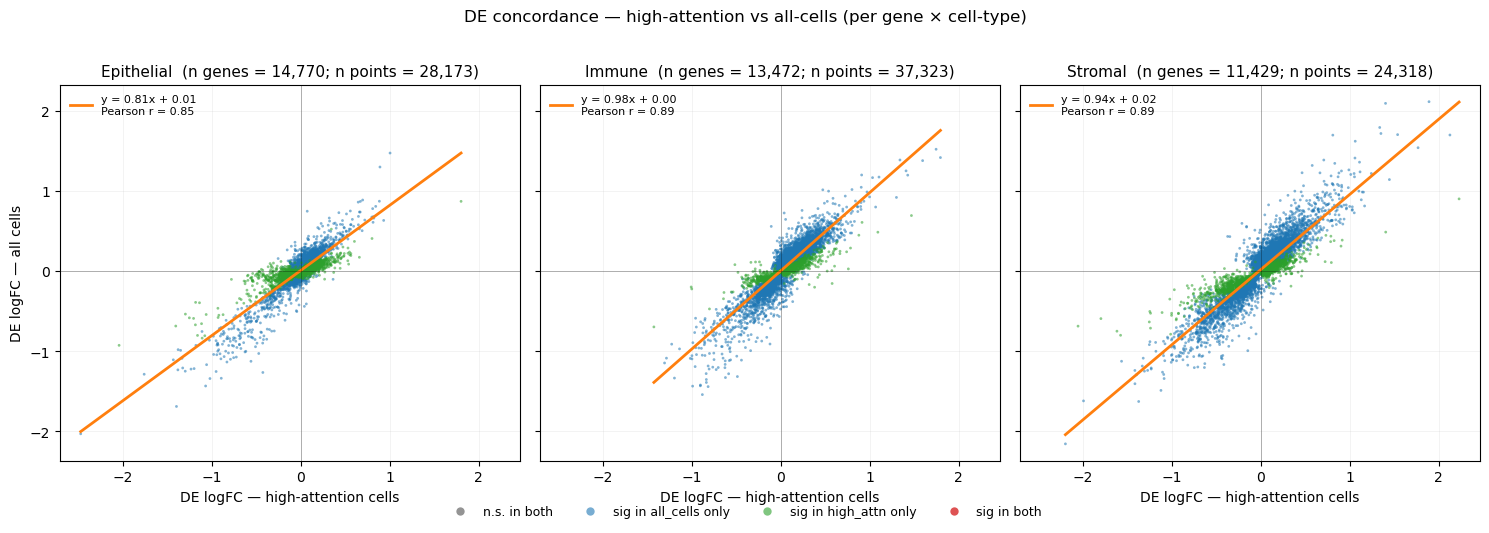

per-CT plots for 56 cell types -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/panelC_per_celltype_exclusive


saved summary -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/panelC_per_celltype_exclusive/_concordance_summary.csv


,cell_type,compartment,n_genes,n_points,slope,intercept,pearson_r,pearson_p,n_sig_ha_only,n_sig_all_only
10,Enterocytes BEST4,Epithelial,1536,1536,0.993193,0.018409,0.905586,0.000000e+00,277,1259
11,Enterocytes CA1 CA2 CA4-,Epithelial,1623,1623,0.583050,-0.002269,0.686805,7.144409e-227,774,849
12,Enterocytes TMIGD1 MEP1A,Epithelial,3075,3075,0.367869,-0.003638,0.298090,3.859380e-64,644,2431
13,Enterocytes TMIGD1 MEP1A GSTA1,Epithelial,60,60,1.035140,0.006491,0.948537,1.189536e-30,1,59
14,Epithelial Cycling cells,Epithelial,1518,1518,0.537316,-0.006453,0.564139,2.793668e-128,540,978
15,Epithelial cells METTL12 MAFB,Epithelial,117,117,0.974433,-0.091587,0.925109,3.464222e-50,6,111
22,Goblet cells MUC2 TFF1,Epithelial,7269,7269,0.358958,0.025923,0.564273,0.000000e+00,656,6613
23,Goblet cells MUC2 TFF1-,Epithelial,3743,3743,0.592927,0.006143,0.616564,0.000000e+00,212,3531
24,Goblet cells SPINK4,Epithelial,279,279,0.803379,0.022655,0.950916,3.941794e-143,86,193
28,L cells,Epithelial,42,42,0.814363,0.141587,0.936759,7.702156e-20,15,27


In [18]:
# Figure-3C scatter restricted to genes significant in exactly ONE mode
EXCL_FIG = os.path.join(FIG_DIR, "panelC_logFC_concordance_exclusive.png")
EXCL_DIR = os.path.join(FIG_DIR, "panelC_per_celltype_exclusive")
os.makedirs(EXCL_DIR, exist_ok=True)

merged_excl = merged_de[merged_de["sig_class"].isin(["ha_only", "all_only"])].copy()
print(f"genes (sig in exactly one mode): {len(merged_excl):,} / {len(merged_de):,}")
print(merged_excl["sig_class"].value_counts())

# 3-compartment summary
plot_concordance(merged_excl, savepath=EXCL_FIG)
plt.show()

# Per-cell-type
common_cts_excl = sorted(merged_excl["cell_type"].unique())
print(f"per-CT plots for {len(common_cts_excl)} cell types -> {EXCL_DIR}")

excl_summary = []
for ct in common_cts_excl:
    sub  = merged_excl[merged_excl["cell_type"] == ct]
    if sub.empty: continue
    comp = sub["compartment"].iloc[0]
    out  = os.path.join(EXCL_DIR, f"{safe_filename(ct)}.png")
    plot_concordance_one_ct(sub, ct, comp, out)

    x = sub["logFC_ha"].to_numpy(); y = sub["logFC_all"].to_numpy()
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    if len(x) >= 2 and np.ptp(x) > 0:
        slope, intercept, r, p, _ = stats.linregress(x, y)
    else:
        slope = intercept = r = p = np.nan
    excl_summary.append({
        "cell_type": ct, "compartment": comp,
        "n_genes": sub["gene"].nunique(),
        "n_points": len(sub),
        "slope": slope, "intercept": intercept,
        "pearson_r": r, "pearson_p": p,
        "n_sig_ha_only":  int((sub["sig_class"] == "ha_only").sum()),
        "n_sig_all_only": int((sub["sig_class"] == "all_only").sum()),
    })

excl_df = pd.DataFrame(excl_summary).sort_values(["compartment", "cell_type"])
excl_csv = os.path.join(EXCL_DIR, "_concordance_summary.csv")
excl_df.to_csv(excl_csv, index=False)
print(f"saved summary -> {excl_csv}")
excl_df.head(15)


## Hallmark pathways significant **only in high-attention cells** — 4 selected cell types

For `Plasma_cells`, `Macrophages`, `T_cells_Naive_CD4`, and `T_cells_CD8`, identify Hallmark pathways that are significant (`padj < PADJ_CUT`) in the **high-attention** run but **not** in the **all-cells** run. Output a long-format table with NES and padj for both modes, plus a per-cell-type count summary.

Outputs:
- `results/hallmark_all_celltypes/hallmark_ha_only_4cts.csv` — full long-format table
- `results/hallmark_all_celltypes/hallmark_ha_only_4cts_counts.csv` — count summary


In [19]:
# Hallmark pathways sig ONLY in high-attn for 4 selected cell types
SELECTED_CTS = ["Plasma_cells", "Macrophages", "T_cells_Naive_CD4", "T_cells_CD8"]

ha_h  = fg_h_ha [["cell_type", "pathway", "NES", "padj"]].copy()
all_h = fg_h_all[["cell_type", "pathway", "NES", "padj"]].copy()

ha_sel  = ha_h [ha_h ["cell_type"].isin(SELECTED_CTS)]
all_sel = all_h[all_h["cell_type"].isin(SELECTED_CTS)]

merged_sel = ha_sel.merge(
    all_sel, on=["cell_type", "pathway"], how="outer",
    suffixes=("_high_attn", "_all_cells"),
)

sig_ha  = merged_sel["padj_high_attn"].lt(PADJ_CUT).fillna(False)
sig_all = merged_sel["padj_all_cells"].lt(PADJ_CUT).fillna(False)
ha_only_mask = sig_ha & ~sig_all

ha_only_tbl = merged_sel[ha_only_mask].copy()
ha_only_tbl["direction"] = np.where(ha_only_tbl["NES_high_attn"] > 0, "Up", "Down")
ha_only_tbl = ha_only_tbl[[
    "cell_type", "pathway", "direction",
    "NES_high_attn", "padj_high_attn",
    "NES_all_cells",  "padj_all_cells",
]].sort_values(["cell_type", "padj_high_attn"]).reset_index(drop=True)

out_dir = HALLMARK_DIR
out_long = os.path.join(out_dir, "hallmark_ha_only_4cts.csv")
ha_only_tbl.to_csv(out_long, index=False)
print(f"saved {len(ha_only_tbl)} (cell_type x pathway) rows -> {out_long}")

counts = (ha_only_tbl.groupby("cell_type")
          .agg(n_pathways=("pathway", "nunique"),
               n_up=("direction", lambda s: (s == "Up").sum()),
               n_down=("direction", lambda s: (s == "Down").sum()))
          .reindex(SELECTED_CTS).fillna(0).astype(int).reset_index())
out_counts = os.path.join(out_dir, "hallmark_ha_only_4cts_counts.csv")
counts.to_csv(out_counts, index=False)
print(f"saved per-cell-type counts -> {out_counts}\n")

print("=== Per-cell-type count of Hallmark pathways sig ONLY in high-attn ===")
print(counts.to_string(index=False))

print("\n=== Full table (cell_type x pathway, NES + padj for both modes) ===")
with pd.option_context("display.max_rows", None, "display.width", 160,
                       "display.float_format", lambda x: f"{x:.3g}"):
    print(ha_only_tbl.to_string(index=False))

ha_only_tbl.head(20)


saved 6 (cell_type x pathway) rows -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/hallmark_all_celltypes/hallmark_ha_only_4cts.csv
saved per-cell-type counts -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/hallmark_all_celltypes/hallmark_ha_only_4cts_counts.csv

=== Per-cell-type count of Hallmark pathways sig ONLY in high-attn ===
        cell_type  n_pathways  n_up  n_down
     Plasma_cells           0     0       0
      Macrophages           1     1       0
T_cells_Naive_CD4           0     0       0
      T_cells_CD8           5     1       4

=== Full table (cell_type x pathway, NES + padj for both modes) ===
  cell_type                            pathway direction

,cell_type,pathway,direction,NES_high_attn,padj_high_attn,NES_all_cells,padj_all_cells
0,Macrophages,HALLMARK_INTERFERON_ALPHA_RESPONSE,Up,1.652485,0.016429,1.408960,0.056060
1,T_cells_CD8,HALLMARK_HYPOXIA,Down,-1.763126,0.006055,-1.371896,0.272893
2,T_cells_CD8,HALLMARK_OXIDATIVE_PHOSPHORYLATION,Down,-1.705092,0.006055,0.894096,0.830253
3,T_cells_CD8,HALLMARK_GLYCOLYSIS,Down,-1.679918,0.010503,-1.458455,0.138166
4,T_cells_CD8,HALLMARK_INTERFERON_GAMMA_RESPONSE,Down,-1.570109,0.028675,-1.226994,0.515861
5,T_cells_CD8,HALLMARK_MITOTIC_SPINDLE,Up,1.615836,0.028675,1.441851,0.138166


## C7 pathways significant **only in high-attention cells** — 4 selected cell types

Same analysis as the Hallmark section above, but using the **C7 (immunologic signatures)** collection. For `Plasma_cells`, `Macrophages`, `T_cells_Naive_CD4`, and `T_cells_CD8`, identify C7 pathways significant in the **high-attention** run but **not** in the **all-cells** run.

Outputs:
- `results/c7_all_celltypes/c7_ha_only_4cts.csv` — full long-format table
- `results/c7_all_celltypes/c7_ha_only_4cts_counts.csv` — count summary


In [20]:
# C7 pathways sig ONLY in high-attn for 4 selected cell types
SELECTED_CTS = ["Plasma_cells", "Macrophages", "T_cells_Naive_CD4", "T_cells_CD8"]

ha_c7_sel  = fg_c7_ha [["cell_type", "pathway", "NES", "padj"]]
ha_c7_sel  = ha_c7_sel [ha_c7_sel ["cell_type"].isin(SELECTED_CTS)]
all_c7_sel = fg_c7_all[["cell_type", "pathway", "NES", "padj"]]
all_c7_sel = all_c7_sel[all_c7_sel["cell_type"].isin(SELECTED_CTS)]

merged_c7_sel = ha_c7_sel.merge(
    all_c7_sel, on=["cell_type", "pathway"], how="outer",
    suffixes=("_high_attn", "_all_cells"),
)

sig_ha  = merged_c7_sel["padj_high_attn"].lt(PADJ_CUT).fillna(False)
sig_all = merged_c7_sel["padj_all_cells"].lt(PADJ_CUT).fillna(False)
ha_only_mask = sig_ha & ~sig_all

c7_ha_only_tbl = merged_c7_sel[ha_only_mask].copy()
c7_ha_only_tbl["direction"] = np.where(c7_ha_only_tbl["NES_high_attn"] > 0, "Up", "Down")
c7_ha_only_tbl = c7_ha_only_tbl[[
    "cell_type", "pathway", "direction",
    "NES_high_attn", "padj_high_attn",
    "NES_all_cells",  "padj_all_cells",
]].sort_values(["cell_type", "padj_high_attn"]).reset_index(drop=True)

out_long = os.path.join(C7_DIR, "c7_ha_only_4cts.csv")
c7_ha_only_tbl.to_csv(out_long, index=False)
print(f"saved {len(c7_ha_only_tbl)} (cell_type x pathway) rows -> {out_long}")

c7_counts = (c7_ha_only_tbl.groupby("cell_type")
             .agg(n_pathways=("pathway", "nunique"),
                  n_up=("direction", lambda s: (s == "Up").sum()),
                  n_down=("direction", lambda s: (s == "Down").sum()))
             .reindex(SELECTED_CTS).fillna(0).astype(int).reset_index())
out_counts = os.path.join(C7_DIR, "c7_ha_only_4cts_counts.csv")
c7_counts.to_csv(out_counts, index=False)
print(f"saved per-cell-type counts -> {out_counts}\n")

print("=== Per-cell-type count of C7 pathways sig ONLY in high-attn ===")
print(c7_counts.to_string(index=False))

# Show top 15 per cell type (by padj_high_attn) — full list can be huge for C7
print("\n=== Top 15 per cell type (by padj_high_attn) ===")
top_per_ct = (c7_ha_only_tbl.groupby("cell_type", group_keys=False)
              .apply(lambda d: d.nsmallest(15, "padj_high_attn")))
with pd.option_context("display.max_rows", None, "display.width", 180,
                       "display.float_format", lambda x: f"{x:.3g}"):
    print(top_per_ct.to_string(index=False))

c7_ha_only_tbl.head(20)


saved 148 (cell_type x pathway) rows -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/c7_all_celltypes/c7_ha_only_4cts.csv
saved per-cell-type counts -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/c7_all_celltypes/c7_ha_only_4cts_counts.csv

=== Per-cell-type count of C7 pathways sig ONLY in high-attn ===
        cell_type  n_pathways  n_up  n_down
     Plasma_cells           0     0       0
      Macrophages          52    42      10
T_cells_Naive_CD4           0     0       0
      T_cells_CD8          96     5      91

=== Top 15 per cell type (by padj_high_attn) ===
  cell_type                                                                           pathway direction

/tmp/ipykernel_461773/1281002161.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.nsmallest(15, "padj_high_attn")))


,cell_type,pathway,direction,NES_high_attn,padj_high_attn,NES_all_cells,padj_all_cells
0,Macrophages,GSE1740_UNSTIM_VS_IFNA_STIMULATED_MCSF_DERIVED...,Up,1.858825,0.004345,1.396170,0.110853
1,Macrophages,GSE25088_ROSIGLITAZONE_VS_IL4_AND_ROSIGLITAZON...,Up,1.759877,0.004345,1.400568,0.058839
2,Macrophages,GSE1112_HY_CD8AB_VS_HY_CD8AA_THYMOCYTE_RTOC_CU...,Up,1.785056,0.006054,1.363936,0.159117
3,Macrophages,GSE24634_TEFF_VS_TCONV_DAY10_IN_CULTURE_DN,Up,1.645979,0.008012,1.376953,0.082659
4,Macrophages,GSE9006_HEALTHY_VS_TYPE_1_DIABETES_PBMC_1MONTH...,Up,1.642552,0.008012,1.393543,0.059537
5,Macrophages,GSE1432_1H_VS_24H_IFNG_MICROGLIA_DN,Up,1.643537,0.010089,1.340101,0.142354
6,Macrophages,GSE12845_IGD_NEG_BLOOD_VS_DARKZONE_GC_TONSIL_B...,Up,1.667757,0.010826,1.407940,0.070046
7,Macrophages,GSE360_HIGH_DOSE_B_MALAYI_VS_M_TUBERCULOSIS_DC_DN,Up,1.650056,0.011632,1.406481,0.061770
8,Macrophages,GSE24671_CTRL_VS_SENDAI_VIRUS_INFECTED_MOUSE_S...,Up,1.713741,0.012962,1.446572,0.057393
9,Macrophages,GSE23398_WT_VS_IL2_KO_CD4_TCELL_SCURFY_MOUSE_UP,Up,1.651537,0.014260,1.395980,0.086915


## Hallmark pathways significant **only in all-cells** — 4 selected cell types

Mirror of the high-attn-only analysis: for `Plasma_cells`, `Macrophages`, `T_cells_Naive_CD4`, and `T_cells_CD8`, identify Hallmark pathways significant in the **all-cells** run but **not** in the **high-attention** run.

Outputs:
- `results/hallmark_all_celltypes/hallmark_all_only_4cts.csv`
- `results/hallmark_all_celltypes/hallmark_all_only_4cts_counts.csv`


In [21]:
# Hallmark pathways sig ONLY in all-cells for 4 selected cell types
SELECTED_CTS = ["Plasma_cells", "Macrophages", "T_cells_Naive_CD4", "T_cells_CD8"]

ha_h_sel  = fg_h_ha [["cell_type", "pathway", "NES", "padj"]]
ha_h_sel  = ha_h_sel [ha_h_sel ["cell_type"].isin(SELECTED_CTS)]
all_h_sel = fg_h_all[["cell_type", "pathway", "NES", "padj"]]
all_h_sel = all_h_sel[all_h_sel["cell_type"].isin(SELECTED_CTS)]

merged_h_sel = ha_h_sel.merge(
    all_h_sel, on=["cell_type", "pathway"], how="outer",
    suffixes=("_high_attn", "_all_cells"),
)

sig_ha  = merged_h_sel["padj_high_attn"].lt(PADJ_CUT).fillna(False)
sig_all = merged_h_sel["padj_all_cells"].lt(PADJ_CUT).fillna(False)
all_only_mask = sig_all & ~sig_ha

h_all_only_tbl = merged_h_sel[all_only_mask].copy()
h_all_only_tbl["direction"] = np.where(h_all_only_tbl["NES_all_cells"] > 0, "Up", "Down")
h_all_only_tbl = h_all_only_tbl[[
    "cell_type", "pathway", "direction",
    "NES_high_attn", "padj_high_attn",
    "NES_all_cells",  "padj_all_cells",
]].sort_values(["cell_type", "padj_all_cells"]).reset_index(drop=True)

out_long = os.path.join(HALLMARK_DIR, "hallmark_all_only_4cts.csv")
h_all_only_tbl.to_csv(out_long, index=False)
print(f"saved {len(h_all_only_tbl)} (cell_type x pathway) rows -> {out_long}")

h_counts = (h_all_only_tbl.groupby("cell_type")
            .agg(n_pathways=("pathway", "nunique"),
                 n_up=("direction", lambda s: (s == "Up").sum()),
                 n_down=("direction", lambda s: (s == "Down").sum()))
            .reindex(SELECTED_CTS).fillna(0).astype(int).reset_index())
out_counts = os.path.join(HALLMARK_DIR, "hallmark_all_only_4cts_counts.csv")
h_counts.to_csv(out_counts, index=False)
print(f"saved per-cell-type counts -> {out_counts}\n")

print("=== Per-cell-type count of Hallmark pathways sig ONLY in all-cells ===")
print(h_counts.to_string(index=False))

print("\n=== Full table ===")
with pd.option_context("display.max_rows", None, "display.width", 160,
                       "display.float_format", lambda x: f"{x:.3g}"):
    print(h_all_only_tbl.to_string(index=False))

h_all_only_tbl.head(20)


saved 2 (cell_type x pathway) rows -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/hallmark_all_celltypes/hallmark_all_only_4cts.csv


saved per-cell-type counts -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/hallmark_all_celltypes/hallmark_all_only_4cts_counts.csv

=== Per-cell-type count of Hallmark pathways sig ONLY in all-cells ===
        cell_type  n_pathways  n_up  n_down
     Plasma_cells           0     0       0
      Macrophages           1     1       0
T_cells_Naive_CD4           1     1       0
      T_cells_CD8           0     0       0

=== Full table ===
        cell_type                          pathway direction  NES_high_attn  padj_high_attn  NES_all_cells  padj_all_cells
      Macrophages HALLMARK_IL6_JAK_STAT3_SIGNALING        Up           1.46           0.136           1.49           0.022
T_cells_Naive_CD4         HALLMARK_MITOTIC_SPINDLE        Up           1.53          0.0714           1.58         0.00436


,cell_type,pathway,direction,NES_high_attn,padj_high_attn,NES_all_cells,padj_all_cells
0,Macrophages,HALLMARK_IL6_JAK_STAT3_SIGNALING,Up,1.457951,0.136344,1.492198,0.021984
1,T_cells_Naive_CD4,HALLMARK_MITOTIC_SPINDLE,Up,1.526104,0.071390,1.582213,0.004356


## C7 pathways significant **only in all-cells** — 4 selected cell types

Same as above but for the **C7 (immunologic signatures)** collection.

Outputs:
- `results/c7_all_celltypes/c7_all_only_4cts.csv`
- `results/c7_all_celltypes/c7_all_only_4cts_counts.csv`


In [22]:
# C7 pathways sig ONLY in all-cells for 4 selected cell types
SELECTED_CTS = ["Plasma_cells", "Macrophages", "T_cells_Naive_CD4", "T_cells_CD8"]

ha_c7_sel  = fg_c7_ha [["cell_type", "pathway", "NES", "padj"]]
ha_c7_sel  = ha_c7_sel [ha_c7_sel ["cell_type"].isin(SELECTED_CTS)]
all_c7_sel = fg_c7_all[["cell_type", "pathway", "NES", "padj"]]
all_c7_sel = all_c7_sel[all_c7_sel["cell_type"].isin(SELECTED_CTS)]

merged_c7_sel = ha_c7_sel.merge(
    all_c7_sel, on=["cell_type", "pathway"], how="outer",
    suffixes=("_high_attn", "_all_cells"),
)

sig_ha  = merged_c7_sel["padj_high_attn"].lt(PADJ_CUT).fillna(False)
sig_all = merged_c7_sel["padj_all_cells"].lt(PADJ_CUT).fillna(False)
all_only_mask = sig_all & ~sig_ha

c7_all_only_tbl = merged_c7_sel[all_only_mask].copy()
c7_all_only_tbl["direction"] = np.where(c7_all_only_tbl["NES_all_cells"] > 0, "Up", "Down")
c7_all_only_tbl = c7_all_only_tbl[[
    "cell_type", "pathway", "direction",
    "NES_high_attn", "padj_high_attn",
    "NES_all_cells",  "padj_all_cells",
]].sort_values(["cell_type", "padj_all_cells"]).reset_index(drop=True)

out_long = os.path.join(C7_DIR, "c7_all_only_4cts.csv")
c7_all_only_tbl.to_csv(out_long, index=False)
print(f"saved {len(c7_all_only_tbl)} (cell_type x pathway) rows -> {out_long}")

c7_counts = (c7_all_only_tbl.groupby("cell_type")
             .agg(n_pathways=("pathway", "nunique"),
                  n_up=("direction", lambda s: (s == "Up").sum()),
                  n_down=("direction", lambda s: (s == "Down").sum()))
             .reindex(SELECTED_CTS).fillna(0).astype(int).reset_index())
out_counts = os.path.join(C7_DIR, "c7_all_only_4cts_counts.csv")
c7_counts.to_csv(out_counts, index=False)
print(f"saved per-cell-type counts -> {out_counts}\n")

print("=== Per-cell-type count of C7 pathways sig ONLY in all-cells ===")
print(c7_counts.to_string(index=False))

print("\n=== Top 15 per cell type (by padj_all_cells) ===")
top_per_ct = (c7_all_only_tbl.groupby("cell_type", group_keys=False)
              .apply(lambda d: d.nsmallest(15, "padj_all_cells"), include_groups=False))
with pd.option_context("display.max_rows", None, "display.width", 180,
                       "display.float_format", lambda x: f"{x:.3g}"):
    print(top_per_ct.to_string())

c7_all_only_tbl.head(20)


saved 49 (cell_type x pathway) rows -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/c7_all_celltypes/c7_all_only_4cts.csv
saved per-cell-type counts -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/c7_all_celltypes/c7_all_only_4cts_counts.csv

=== Per-cell-type count of C7 pathways sig ONLY in all-cells ===
        cell_type  n_pathways  n_up  n_down
     Plasma_cells           0     0       0
      Macrophages          11    11       0
T_cells_Naive_CD4          30     9      21
      T_cells_CD8           8     0       8

=== Top 15 per cell type (by padj_all_cells) ===
                                                                        pathway direction  NES_high_at

,cell_type,pathway,direction,NES_high_attn,padj_high_attn,NES_all_cells,padj_all_cells
0,Macrophages,GSE22886_NAIVE_CD8_TCELL_VS_NEUTROPHIL_DN,Up,1.562098,0.099749,1.512387,0.016588
1,Macrophages,GSE30083_SP2_VS_SP4_THYMOCYTE_DN,Up,1.583932,0.050462,1.479831,0.019869
2,Macrophages,GSE22886_NAIVE_CD4_TCELL_VS_NEUTROPHIL_DN,Up,1.574412,0.073083,1.493985,0.022065
3,Macrophages,GSE45365_NK_CELL_VS_CD11B_DC_DN,Up,1.520904,0.073109,1.449637,0.026260
4,Macrophages,GSE9988_LOW_LPS_VS_ANTI_TREM1_AND_LPS_MONOCYTE_UP,Up,1.397459,0.221869,1.432949,0.038717
5,Macrophages,GSE24634_TEFF_VS_TCONV_DAY7_IN_CULTURE_DN,Up,1.497860,0.084029,1.418224,0.038873
6,Macrophages,GSE22886_NAIVE_CD8_TCELL_VS_MONOCYTE_DN,Up,1.524587,0.050318,1.414447,0.039729
7,Macrophages,GSE30083_SP3_VS_SP4_THYMOCYTE_DN,Up,1.513721,0.111271,1.442262,0.040393
8,Macrophages,GSE9988_LPS_VS_LPS_AND_ANTI_TREM1_MONOCYTE_UP,Up,1.287929,0.370533,1.418115,0.040393
9,Macrophages,GSE3982_EFF_MEMORY_CD4_TCELL_VS_NKCELL_UP,Up,1.499967,0.170573,1.472175,0.043953


## Epithelial 4-cell-type comparison — Hallmark & C7 (HA-only and all-only)

Same exclusive-pathway analysis as above, but for four epithelial cell types: `Enterocytes_CA1_CA2_CA4-`, `Enterocytes_TMIGD1_MEP1A`, `Stem_cells_OLFM4`, and `Stem_cells_OLFM4_LGR5`. Reports pathways significant **only in high-attention** and **only in all-cells**, for both Hallmark and C7 collections.

Outputs (under `results/`):
- `hallmark_all_celltypes/hallmark_ha_only_4epith.csv` (+ `_counts.csv`)
- `hallmark_all_celltypes/hallmark_all_only_4epith.csv` (+ `_counts.csv`)
- `c7_all_celltypes/c7_ha_only_4epith.csv` (+ `_counts.csv`)
- `c7_all_celltypes/c7_all_only_4epith.csv` (+ `_counts.csv`)


In [23]:
# Exclusive-pathway analysis for 4 epithelial cell types — Hallmark + C7
EPITH_CTS = [
    "Enterocytes_CA1_CA2_CA4-",
    "Enterocytes_TMIGD1_MEP1A",
    "Stem_cells_OLFM4",
    "Stem_cells_OLFM4_LGR5",
]

def exclusive_pathways(fg_ha_df, fg_all_df, cts, padj_cut=PADJ_CUT):
    cols = ["cell_type", "pathway", "NES", "padj"]
    a = fg_ha_df [cols]; a = a[a["cell_type"].isin(cts)]
    b = fg_all_df[cols]; b = b[b["cell_type"].isin(cts)]
    m = a.merge(b, on=["cell_type", "pathway"], how="outer",
                suffixes=("_high_attn", "_all_cells"))
    sig_ha  = m["padj_high_attn"].lt(padj_cut).fillna(False)
    sig_all = m["padj_all_cells"].lt(padj_cut).fillna(False)

    def _tbl(mask, ref_nes_col, sort_col):
        t = m[mask].copy()
        t["direction"] = np.where(t[ref_nes_col] > 0, "Up", "Down")
        return t[[
            "cell_type", "pathway", "direction",
            "NES_high_attn", "padj_high_attn",
            "NES_all_cells",  "padj_all_cells",
        ]].sort_values(["cell_type", sort_col]).reset_index(drop=True)

    ha_only_tbl  = _tbl(sig_ha  & ~sig_all, "NES_high_attn", "padj_high_attn")
    all_only_tbl = _tbl(sig_all & ~sig_ha,  "NES_all_cells", "padj_all_cells")
    return ha_only_tbl, all_only_tbl

def counts_table(tbl, cts):
    return (tbl.groupby("cell_type")
              .agg(n_pathways=("pathway", "nunique"),
                   n_up=("direction", lambda s: (s == "Up").sum()),
                   n_down=("direction", lambda s: (s == "Down").sum()))
              .reindex(cts).fillna(0).astype(int).reset_index())

def run_block(fg_ha_df, fg_all_df, cts, label, out_dir, prefix):
    ha_only_tbl, all_only_tbl = exclusive_pathways(fg_ha_df, fg_all_df, cts)
    ha_counts  = counts_table(ha_only_tbl,  cts)
    all_counts = counts_table(all_only_tbl, cts)

    for tbl, tag, cnt in [(ha_only_tbl,  "ha_only",  ha_counts),
                          (all_only_tbl, "all_only", all_counts)]:
        long_path = os.path.join(out_dir, f"{prefix}_{tag}_4epith.csv")
        cnt_path  = os.path.join(out_dir, f"{prefix}_{tag}_4epith_counts.csv")
        tbl.to_csv(long_path, index=False)
        cnt.to_csv(cnt_path,  index=False)
        print(f"[{label} {tag}] saved {len(tbl)} rows -> {long_path}")

    print(f"\n=== {label}: pathways sig ONLY in high-attn ===")
    print(ha_counts.to_string(index=False))
    print(f"\n=== {label}: pathways sig ONLY in all-cells ===")
    print(all_counts.to_string(index=False))
    return ha_only_tbl, all_only_tbl, ha_counts, all_counts

print("############ HALLMARK ############")
h_ha_only, h_all_only, h_ha_cnt, h_all_cnt = run_block(
    fg_h_ha, fg_h_all, EPITH_CTS, "Hallmark", HALLMARK_DIR, "hallmark")

print("\n--- Hallmark HA-only full table ---")
with pd.option_context("display.max_rows", None, "display.width", 160,
                       "display.float_format", lambda x: f"{x:.3g}"):
    print(h_ha_only.to_string(index=False))
print("\n--- Hallmark all-only full table ---")
with pd.option_context("display.max_rows", None, "display.width", 160,
                       "display.float_format", lambda x: f"{x:.3g}"):
    print(h_all_only.to_string(index=False))

print("\n\n############ C7 ############")
c7_ha_only, c7_all_only, c7_ha_cnt, c7_all_cnt = run_block(
    fg_c7_ha, fg_c7_all, EPITH_CTS, "C7", C7_DIR, "c7")

print("\n--- C7 HA-only top 10 per cell type (by padj_high_attn) ---")
top_ha = (c7_ha_only.groupby("cell_type", group_keys=False)
          .apply(lambda d: d.nsmallest(10, "padj_high_attn"), include_groups=False))
with pd.option_context("display.max_rows", None, "display.width", 180,
                       "display.float_format", lambda x: f"{x:.3g}"):
    print(top_ha.to_string())

print("\n--- C7 all-only top 10 per cell type (by padj_all_cells) ---")
top_all = (c7_all_only.groupby("cell_type", group_keys=False)
           .apply(lambda d: d.nsmallest(10, "padj_all_cells"), include_groups=False))
with pd.option_context("display.max_rows", None, "display.width", 180,
                       "display.float_format", lambda x: f"{x:.3g}"):
    print(top_all.to_string())

# Combined summary
summary = pd.DataFrame({
    "cell_type": EPITH_CTS,
    "hallmark_ha_only":  h_ha_cnt.set_index("cell_type").reindex(EPITH_CTS)["n_pathways"].values,
    "hallmark_all_only": h_all_cnt.set_index("cell_type").reindex(EPITH_CTS)["n_pathways"].values,
    "c7_ha_only":  c7_ha_cnt.set_index("cell_type").reindex(EPITH_CTS)["n_pathways"].values,
    "c7_all_only": c7_all_cnt.set_index("cell_type").reindex(EPITH_CTS)["n_pathways"].values,
})
print("\n=== Combined summary ===")
print(summary.to_string(index=False))
summary


############ HALLMARK ############


[Hallmark ha_only] saved 3 rows -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/hallmark_all_celltypes/hallmark_ha_only_4epith.csv
[Hallmark all_only] saved 1 rows -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/hallmark_all_celltypes/hallmark_all_only_4epith.csv

=== Hallmark: pathways sig ONLY in high-attn ===
               cell_type  n_pathways  n_up  n_down
Enterocytes_CA1_CA2_CA4-           0     0       0
Enterocytes_TMIGD1_MEP1A           0     0       0
        Stem_cells_OLFM4           0     0       0
   Stem_cells_OLFM4_LGR5           3     3       0

=== Hallmark: pathways sig ONLY in all-cells ===
               cell_type  n_pathways  n_up  n_down
Enterocyte

[C7 ha_only] saved 130 rows -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/c7_all_celltypes/c7_ha_only_4epith.csv


[C7 all_only] saved 68 rows -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/results_logfc/c7_all_celltypes/c7_all_only_4epith.csv

=== C7: pathways sig ONLY in high-attn ===
               cell_type  n_pathways  n_up  n_down
Enterocytes_CA1_CA2_CA4-           0     0       0
Enterocytes_TMIGD1_MEP1A          10     5       5
        Stem_cells_OLFM4          42     7      35
   Stem_cells_OLFM4_LGR5          78    73       5

=== C7: pathways sig ONLY in all-cells ===
               cell_type  n_pathways  n_up  n_down
Enterocytes_CA1_CA2_CA4-           7     7       0
Enterocytes_TMIGD1_MEP1A          36    23      13
        Stem_cells_OLFM4          11     8       3
   Stem_cells_OLFM4_LGR5          14     8       6

--- C7 HA-only top 10 per cell type (by padj_high_attn) ---
                                                              pat

,cell_type,hallmark_ha_only,hallmark_all_only,c7_ha_only,c7_all_only
0,Enterocytes_CA1_CA2_CA4-,0,0,0,7
1,Enterocytes_TMIGD1_MEP1A,0,0,10,36
2,Stem_cells_OLFM4,0,1,42,11
3,Stem_cells_OLFM4_LGR5,3,0,78,14


## Single-panel NES bar plots — mode-exclusive Hallmark pathways across 4 immune cell types

Two horizontal bar plots styled like `figures/hallmark_per_celltype_bipanel/B_cells.png` but in a **single panel**, combining all 4 cell types (`Plasma_cells`, `Macrophages`, `T_cells_Naive_CD4`, `T_cells_CD8`). Bars are coloured by cell type. Pathways are sorted by signed NES.

- Plot 1 (HA-only): from `hallmark_ha_only_4cts.csv`, x = `NES_high_attn`
- Plot 2 (all-only): from `hallmark_all_only_4cts.csv`, x = `NES_all_cells`

Outputs:
- `figures/hallmark_ha_only_4cts_bar.png`
- `figures/hallmark_all_only_4cts_bar.png`


[high-attention cells] saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/hallmark_ha_only_4cts_bar.png  (6 bars)


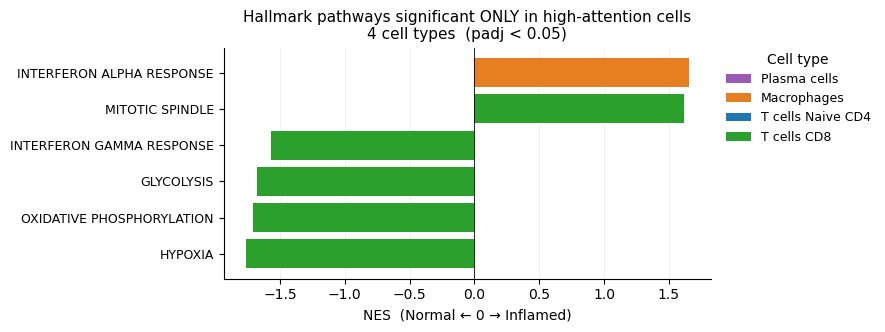

[all cells] saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/hallmark_all_only_4cts_bar.png  (2 bars)


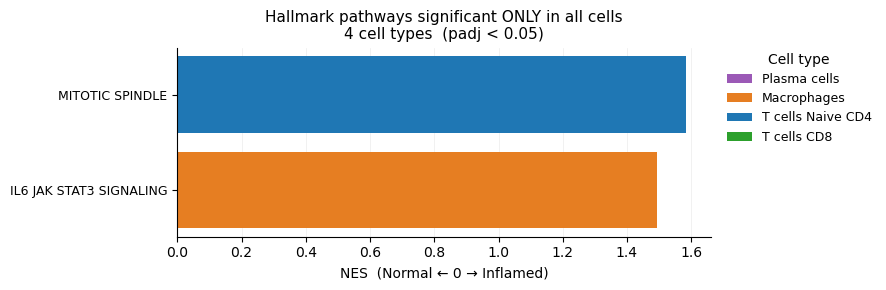

In [24]:
# Single-panel NES bar plots for mode-exclusive Hallmark pathways (4 cell types)
SELECTED_CTS = ["Plasma_cells", "Macrophages", "T_cells_Naive_CD4", "T_cells_CD8"]
CT_COLORS = {
    "Plasma_cells":      "#9B59B6",
    "Macrophages":       "#E67E22",
    "T_cells_Naive_CD4": "#1F77B4",
    "T_cells_CD8":       "#2CA02C",
}

def plot_exclusive_bar(csv_path, nes_col, padj_col, mode_label, savepath):
    df = pd.read_csv(csv_path)
    df = df[df["cell_type"].isin(SELECTED_CTS)].copy()
    if df.empty:
        print(f"[{mode_label}] no rows to plot."); return None

    df["label"] = df["pathway"].str.replace("HALLMARK_", "", regex=False).str.replace("_", " ")
    df = df.sort_values(["cell_type", nes_col], ascending=[True, True]).reset_index(drop=True)
    df = df.sort_values(nes_col, ascending=True).reset_index(drop=True)

    n = len(df)
    fig, ax = plt.subplots(figsize=(9, max(3.0, 0.32 * n + 1.5)))
    ypos = np.arange(n)
    colors = [CT_COLORS[c] for c in df["cell_type"]]
    ax.barh(ypos, df[nes_col], color=colors, edgecolor="none")
    ax.axvline(0, color="black", lw=0.6)
    ax.set_yticks(ypos)
    ax.set_yticklabels(df["label"], fontsize=9)
    ax.set_xlabel("NES  (Normal ← 0 → Inflamed)")
    ax.set_title(f"Hallmark pathways significant ONLY in {mode_label}\n"
                 f"4 cell types  (padj < {PADJ_CUT})", fontsize=11)
    ax.grid(axis="x", alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)

    from matplotlib.patches import Patch
    handles = [Patch(facecolor=CT_COLORS[c], label=c.replace("_", " ")) for c in SELECTED_CTS]
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              borderaxespad=0, frameon=False, fontsize=9, title="Cell type")

    fig.tight_layout()
    fig.savefig(savepath, dpi=200, bbox_inches="tight")
    print(f"[{mode_label}] saved -> {savepath}  ({n} bars)")
    return fig

HA_CSV  = os.path.join(HALLMARK_DIR, "hallmark_ha_only_4cts.csv")
ALL_CSV = os.path.join(HALLMARK_DIR, "hallmark_all_only_4cts.csv")

fig_ha = plot_exclusive_bar(HA_CSV,  "NES_high_attn", "padj_high_attn",
                             "high-attention cells",
                             os.path.join(FIG_DIR, "hallmark_ha_only_4cts_bar.png"))
plt.show()

fig_all = plot_exclusive_bar(ALL_CSV, "NES_all_cells", "padj_all_cells",
                              "all cells",
                              os.path.join(FIG_DIR, "hallmark_all_only_4cts_bar.png"))
plt.show()


## Single-panel NES bar plots — mode-exclusive Hallmark pathways across 4 epithelial cell types

Same style as the immune-cell plots, for the four epithelial cell types: `Enterocytes_CA1_CA2_CA4-`, `Enterocytes_TMIGD1_MEP1A`, `Stem_cells_OLFM4`, `Stem_cells_OLFM4_LGR5`. NES values come from the long-format CSVs (the `_counts.csv` files have no NES).

Outputs:
- `figures/hallmark_ha_only_4epith_bar.png`
- `figures/hallmark_all_only_4epith_bar.png`


[high-attention cells] saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/hallmark_ha_only_4epith_bar.png  (3 bars)


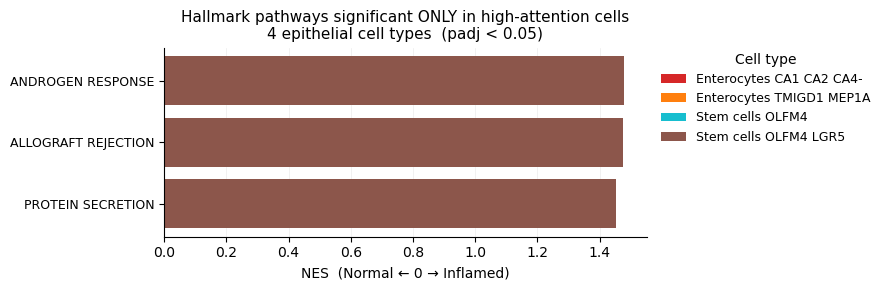

[all cells] saved -> /mnt/custom-file-systems/efs/fs-0a41cadb4a45afe66_fsap-0fc781dabcad1b95d/nihar/single_cell_metric/scripts/kong_hier_mil/Updated_training/Healthy_inflamed/SAP_healthy_inflamed/wilcox_de_fgsea/figures_logfc/hallmark_all_only_4epith_bar.png  (1 bars)


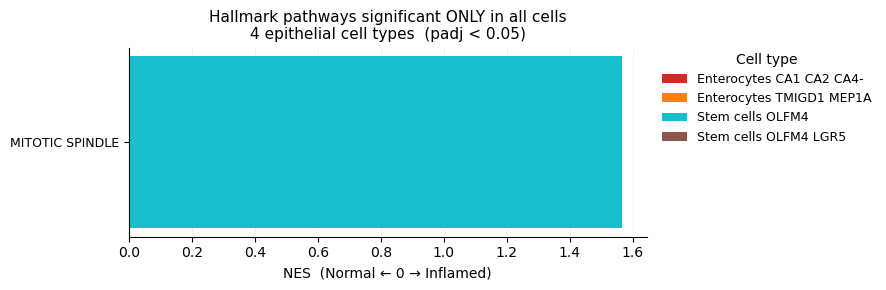

In [25]:
# Single-panel NES bar plots for mode-exclusive Hallmark pathways (4 epithelial cell types)
EPITH_CTS = [
    "Enterocytes_CA1_CA2_CA4-",
    "Enterocytes_TMIGD1_MEP1A",
    "Stem_cells_OLFM4",
    "Stem_cells_OLFM4_LGR5",
]
EPITH_COLORS = {
    "Enterocytes_CA1_CA2_CA4-": "#D62728",
    "Enterocytes_TMIGD1_MEP1A": "#FF7F0E",
    "Stem_cells_OLFM4":         "#17BECF",
    "Stem_cells_OLFM4_LGR5":    "#8C564B",
}

def plot_exclusive_bar_generic(csv_path, nes_col, mode_label, savepath,
                                cts, ct_colors):
    df = pd.read_csv(csv_path)
    df = df[df["cell_type"].isin(cts)].copy()
    if df.empty:
        print(f"[{mode_label}] no rows to plot."); return None

    df["label"] = (df["pathway"].str.replace("HALLMARK_", "", regex=False)
                                  .str.replace("_", " "))
    df = df.sort_values(nes_col, ascending=True).reset_index(drop=True)

    n = len(df)
    fig, ax = plt.subplots(figsize=(9, max(3.0, 0.32 * n + 1.5)))
    ypos = np.arange(n)
    colors = [ct_colors[c] for c in df["cell_type"]]
    ax.barh(ypos, df[nes_col], color=colors, edgecolor="none")
    ax.axvline(0, color="black", lw=0.6)
    ax.set_yticks(ypos)
    ax.set_yticklabels(df["label"], fontsize=9)
    ax.set_xlabel("NES  (Normal ← 0 → Inflamed)")
    ax.set_title(f"Hallmark pathways significant ONLY in {mode_label}\n"
                 f"4 epithelial cell types  (padj < {PADJ_CUT})", fontsize=11)
    ax.grid(axis="x", alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)

    from matplotlib.patches import Patch
    handles = [Patch(facecolor=ct_colors[c], label=c.replace("_", " ")) for c in cts]
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              borderaxespad=0, frameon=False, fontsize=9, title="Cell type")

    fig.tight_layout()
    fig.savefig(savepath, dpi=200, bbox_inches="tight")
    print(f"[{mode_label}] saved -> {savepath}  ({n} bars)")
    return fig

HA_CSV_E  = os.path.join(HALLMARK_DIR, "hallmark_ha_only_4epith.csv")
ALL_CSV_E = os.path.join(HALLMARK_DIR, "hallmark_all_only_4epith.csv")

plot_exclusive_bar_generic(HA_CSV_E,  "NES_high_attn",
                            "high-attention cells",
                            os.path.join(FIG_DIR, "hallmark_ha_only_4epith_bar.png"),
                            EPITH_CTS, EPITH_COLORS)
plt.show()

plot_exclusive_bar_generic(ALL_CSV_E, "NES_all_cells",
                            "all cells",
                            os.path.join(FIG_DIR, "hallmark_all_only_4epith_bar.png"),
                            EPITH_CTS, EPITH_COLORS)
plt.show()
